In [1]:
%pip install matplotlib seaborn pandas numpy statsmodels scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


**Summary**

This project aims to predict the daily sales of 1,115 Rossmann stores across Europe for up to six weeks in advance using machine learning regression models. The model takes into consideration various factors that influence store sales, such as promotions, competition, holidays, seasonality, and locality.


# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#to display all the graph in the workbook
%matplotlib inline
sns.set_style("whitegrid",{'grid.linestyle': '--'})
import warnings
warnings.filterwarnings("ignore")


# **Read dataset**

In [2]:
sales_data = pd.read_csv('train.csv',low_memory=False)
store_data= pd.read_csv('store.csv',low_memory=False)

In [3]:
sales_data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
sales_data.tail(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017199,1106,2,2013-01-01,0,0,0,0,a,1
1017200,1107,2,2013-01-01,0,0,0,0,a,1
1017201,1108,2,2013-01-01,0,0,0,0,a,1
1017202,1109,2,2013-01-01,0,0,0,0,a,1
1017203,1110,2,2013-01-01,0,0,0,0,a,1
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


In [5]:
sales_data.StateHoliday.unique()

<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str

In [6]:
store_data.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
store_data.tail()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1114,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


**Dataset Rows & Columns count**

In [8]:
sales_data.shape

(1017209, 9)

In [9]:
sales_data.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='str')

In [10]:
store_data.shape

(1115, 10)

In [11]:
store_data.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

**Dataset Information**

In [12]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 69.8 MB


In [13]:
#checking description of data #sales
sales_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0


### Descriptive Statistics Insights

- **Count:** 1,017,209 records across all columns, indicating a large dataset with **no missing values**.
- **Store:** Includes data for **1,115** unique stores.
- **Sales:** 
  - **Mean:** ~5,773. 
  - **Min/Max:** Ranges from 0 (closed days) to 41,551 (peak sales days). 
  - **Median (5,744):** Very close to the mean, indicating a nearly normal distribution without heavy skewness.
- **Customers:** Averages ~633 customers per day, ranging from 0 to 7,388.
- **Open:** Mean is 0.83, meaning stores are open on exactly **83%** of the recorded days. The remaining 17% represents closures (e.g., Sundays, holidays) where sales and customers are exactly 0.
- **Promo:** Stores run active promotions on **38%** of the days.
- **SchoolHoliday:** School holidays account for **17.8%** of the days in the dataset.

The **17% closure rate** (yielding 0 sales) is a crucial pattern. These zero-sales days must be handled


In [14]:
store_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [15]:
#checking description of data # store
store_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Store,1115.0,558.000000,322.017080,1.0,279.5,558.0,836.5,1115.0
CompetitionDistance,1112.0,5404.901079,7663.174720,20.0,717.5,2325.0,6882.5,75860.0
CompetitionOpenSinceMonth,761.0,7.224704,3.212348,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,761.0,2008.668857,6.195983,1900.0,2006.0,2010.0,2013.0,2015.0
Promo2,1115.0,0.512108,0.500078,0.0,0.0,1.0,1.0,1.0
Promo2SinceWeek,571.0,23.595447,14.141984,1.0,13.0,22.0,37.0,50.0
Promo2SinceYear,571.0,2011.763573,1.674935,2009.0,2011.0,2012.0,2013.0,2015.0


### Store Data Descriptive Statistics Insights

- **Store:** Contains data for exactly **1,115** stores.
- **CompetitionDistance:** 
  - **Missing Values:** Only 3 values are missing (1,112 out of 1,115).
  - **Distance:** The closest competitor is just **20 meters** away, while the furthest is **75,860 meters** (approx. 76 km).
  - **Skewness:** The median distance (2,325m) is much lower than the mean (5,405m), indicating that most stores have competitors relatively close by, with only a few outliers having very distant competitors.
- **CompetitionOpenSince (Month/Year):** 
  - Has a significant number of missing values (only 761 out of 1,115 recorded).
  - The oldest competitor in the dataset opened in **1900**, and the newest in **2015**.
- **Promo2 (Continuous Promotion):** 
  - The mean is ~0.51, meaning exactly **51.2%** of the stores participate in continuous and consecutive promotions.
- **Promo2Since (Week/Year):** 
  - Only has **571** records, which perfectly matches the 51.2% of stores participating in `Promo2`. The remaining values are naturally missing (NaN) because those stores do not participate in Promo2.

The primary challenge in this table is handling **Missing Values**. While `Promo2Since` missing values are logically explained (store doesn't run Promo2), the missing values in `CompetitionDistance` and `CompetitionOpenSince` need careful imputation (e.g., replacing missing distances with a very large number or the max distance, assuming the competitor is practically non-existent).


In [16]:
# check doublication
duplicates = sales_data.duplicated(
    subset=[
        'Store', 'DayOfWeek', 'Date', 'Sales', 'Customers',
        'Open', 'Promo', 'StateHoliday', 'SchoolHoliday'
    ],
    keep=False
)

sales_data[duplicates]


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday


**Missing Values/Null Values**

In [17]:
sales_data.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [18]:
store_data.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [19]:
#Here I want to know the missing values in percentage
store_null = store_data.apply(pd.isnull).sum()/store_data.shape[0]
store_null.round(2)

Store                        0.00
StoreType                    0.00
Assortment                   0.00
CompetitionDistance          0.00
CompetitionOpenSinceMonth    0.32
CompetitionOpenSinceYear     0.32
Promo2                       0.00
Promo2SinceWeek              0.49
Promo2SinceYear              0.49
PromoInterval                0.49
dtype: float64

In [20]:
store_data.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


###  Handling Missing Values 

**Keep as `NaN` + Add a Binary Flag Feature**

Instead of filling missing values with arbitrary numbers (imputation), it is often better to leave them as `NaN`. This allows the model to naturally recognize that the information is absent.

- **Why?** Advanced algorithms like **Tree-based models** (e.g., XGBoost, LightGBM) and **Deep Learning models** (e.g., Temporal Fusion Transformers (TFT), LSTM) have built-in mechanisms to handle `NaN` values directly or through masking.
- **The Strategy:** Create an additional binary feature (a flag) to explicitly signal to the model whether the data exists or is missing. 

**Implementation Example:**
If we don't know when a competitor opened (`CompetitionOpenSinceYear` is NaN), we can create a new feature called `CompetitionExists`:
- `0` = Data is missing (No information about the competitor).
- `1` = Data exists (We know when the competitor opened).

This "Missing Signal" acts as a strong indicator for the model  so we make this to save the information that is there any compettion or not  because the missing value may mean that there is no any compettion in this area or exist but very far.

In [21]:
# 1: Create binary features FIRST (while NaNs still exist

# These features preserve information about missing data
store_data['HasPromo2'] = store_data['Promo2SinceYear'].notna().astype(int)
store_data['HasCompetition'] = store_data['CompetitionDistance'].notna().astype(int)


# 2: Handle missing values in Promo2 features
store_data['Promo2SinceWeek'] = store_data['Promo2SinceWeek'].fillna(-1)
store_data['Promo2SinceYear'] = store_data['Promo2SinceYear'].fillna(-1)
store_data['PromoInterval'] = store_data['PromoInterval'].fillna('None')


# STEP 3: Handle missing values in Competition features

# Fill CompetitionDistance with a large value (2x max distance)
max_distance = store_data['CompetitionDistance'].max()
store_data['CompetitionDistance'] = store_data['CompetitionDistance'].fillna(max_distance * 2)

# Fill competition opening date with -1 (not applicable)
store_data['CompetitionOpenSinceMonth'] = store_data['CompetitionOpenSinceMonth'].fillna(-1)
store_data['CompetitionOpenSinceYear'] = store_data['CompetitionOpenSinceYear'].fillna(-1)


# STEP 4: Verify results
print(f"HasCompetition distribution:\n{store_data['HasCompetition'].value_counts()}")
print(f"\nRemaining nulls:\n{store_data.isnull().sum().sum()} total")

HasCompetition distribution:
HasCompetition
1    1112
0       3
Name: count, dtype: int64

Remaining nulls:
0 total


In [22]:
# Merge the two datasets based on the 'Store' column on left
total_df = pd.merge(sales_data, store_data, on='Store', how='left')
print("Data has been successfully merged")

Data has been successfully merged


In [23]:
total_df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
HasPromo2                    0
HasCompetition               0
dtype: int64

In [24]:
total_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 20 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionOpenSinceYea

so we need to handle Date,StateHoliday,StoreType,Assortment,PromoInterval

In [25]:
for col in total_df.columns:
    print(f"Column: {col}")
    print(total_df[col].unique())
    print("-" * 30)
    

Column: Store
[   1    2    3 ... 1113 1114 1115]
------------------------------
Column: DayOfWeek
[5 4 3 2 1 7 6]
------------------------------
Column: Date
<StringArray>
['2015-07-31', '2015-07-30', '2015-07-29', '2015-07-28', '2015-07-27',
 '2015-07-26', '2015-07-25', '2015-07-24', '2015-07-23', '2015-07-22',
 ...
 '2013-01-10', '2013-01-09', '2013-01-08', '2013-01-07', '2013-01-06',
 '2013-01-05', '2013-01-04', '2013-01-03', '2013-01-02', '2013-01-01']
Length: 942, dtype: str
------------------------------
Column: Sales
[ 5263  6064  8314 ...   660 17815 23303]
------------------------------
Column: Customers
[ 555  625  821 ... 3900   36 4065]
------------------------------
Column: Open
[1 0]
------------------------------
Column: Promo
[1 0]
------------------------------
Column: StateHoliday
<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str
------------------------------
Column: SchoolHoliday
[1 0]
------------------------------
Column: StoreType
<StringArray>
['c', 'a',

In [26]:
import pandas as pd
import numpy as np

# Month mapping dictionary
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Parse PromoInterval once (vectorized approach)
def parse_promo_intervals(promo_interval_series):
    """Convert PromoInterval strings into lists of month numbers."""
    def parse_single(interval):
        # Handle empty or missing values
        if pd.isna(interval) or interval == '' or interval == 0:
            return []

        # Convert to string if it is a number
        if isinstance(interval, (int, float)):
            interval = str(int(interval))

        # Ensure it is a valid string
        if not isinstance(interval, str):
            return []

        try:
            return [month_map[m.strip()] for m in interval.split(',')]
        except (KeyError, AttributeError):
            return []

    return promo_interval_series.apply(parse_single)

# Calculate Promo2 start dates (vectorized)
def calculate_promo2_start_dates(df):
    """Calculate the exact start date of Promo2 for each row."""
    # Handle missing values: valid rows must have Year > 0 and Week > 0
    valid_mask = (df['Promo2SinceYear'] > 0) & (df['Promo2SinceWeek'] > 0)

    # Initialize empty Series with NaT (Not a Time)
    start_dates = pd.Series(pd.NaT, index=df.index)

    # Calculate dates only for valid rows
    if valid_mask.any():
        years = df.loc[valid_mask, 'Promo2SinceYear'].astype(int)
        weeks = df.loc[valid_mask, 'Promo2SinceWeek'].astype(int)

        # Convert Year + Week into a proper datetime format
        jan_first = pd.to_datetime(years.astype(str) + '-01-01')
        start_dates.loc[valid_mask] = jan_first + pd.to_timedelta((weeks - 1) * 7, unit='d')

    return start_dates

# Optimal Vectorized Solution
def calculate_promo2_active_vectorized(df):
    """
    Calculate IsPromo2Active using a highly optimized vectorized approach.
    """
    # Condition 1: The store actively participates in Promo2
    is_promo2_store = df['Promo2'] == 1

    # Calculate the exact promo start dates
    promo_start_dates = calculate_promo2_start_dates(df)

    # Condition 2: The current date is after or equal to the Promo2 start date
    date_valid = df['Date'] >= promo_start_dates

    # Condition 3: The current month is included within the PromoInterval
    df['_promo_months'] = parse_promo_intervals(df['PromoInterval'])
    month_valid = df.apply(lambda row: row['Date'].month in row['_promo_months']
                           if len(row['_promo_months']) > 0 else False, axis=1)

    # Combine all conditions (All must be True)
    result = is_promo2_store & date_valid & month_valid

    # Clean up temporary column
    df.drop('_promo_months', axis=1, inplace=True)

    return result.astype(int)


In [27]:
# Convert Date column to datetime format first
total_df['Date'] = pd.to_datetime(total_df['Date'], errors='coerce')

# Apply the vectorized function to create the new feature
total_df['IsPromo2Active'] = calculate_promo2_active_vectorized(total_df)

# Verify and print the results
print("Sample Results:")
print(total_df[['Date', 'Store', 'Promo2', 'PromoInterval', 'IsPromo2Active']].head(10))
print("IsPromo2Active Statistics:")
print(total_df['IsPromo2Active'].value_counts())
print(f"\nActivation Rate: {total_df['IsPromo2Active'].mean():.2%}")


Sample Results:
        Date  Store  Promo2    PromoInterval  IsPromo2Active
0 2015-07-31      1       0             None               0
1 2015-07-31      2       1  Jan,Apr,Jul,Oct               1
2 2015-07-31      3       1  Jan,Apr,Jul,Oct               1
3 2015-07-31      4       0             None               0
4 2015-07-31      5       0             None               0
5 2015-07-31      6       0             None               0
6 2015-07-31      7       0             None               0
7 2015-07-31      8       0             None               0
8 2015-07-31      9       0             None               0
9 2015-07-31     10       0             None               0
IsPromo2Active Statistics:
IsPromo2Active
0    865264
1    151945
Name: count, dtype: int64

Activation Rate: 14.94%


### Feature Engineering: Creating `IsPromo2Active`

**What happened here?**
We engineered a highly specific binary feature called `IsPromo2Active`. This feature evaluates whether a continuous promotion (`Promo2`) was actively running in a specific store on a specific date. 

The feature evaluates to `1` (Active) ONLY if **all three** of the following conditions are met:
1. **Participation:** The store actually participates in Promo2 (`Promo2 == 1`).
2. **Start Date Validation:** The current `Date` is on or after the exact start date of the promotion (calculated from `Promo2SinceYear` and `Promo2SinceWeek`).
3. **Month Validation:** The current month matches one of the active promotional months listed in the store's `PromoInterval` (e.g., "Jan,Apr,Jul,Oct").

**Why did we do this?**
- **Enhanced Accuracy:** Raw columns like `Promo2SinceWeek` or `PromoInterval` are static and confusing for machine learning models. Creating a dynamic, date-specific feature (`IsPromo2Active`) directly tells the model whether the promotion was boosting sales on that exact day.
- **Why the "Vectorized" approach?** Processing a dataset with over 1 million rows using a standard `for` loop would take minutes or even hours. The vectorized approach utilizes optimized Pandas/NumPy operations, executing the entire complex logic across all rows in just a few seconds.


In [28]:
total_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,HasPromo2,HasCompetition,IsPromo2Active
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,1270.0,9.0,2008.0,0,-1.0,-1.0,None,0,1,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",1,1,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",1,1,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,-1.0,-1.0,None,0,1,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,29910.0,4.0,2015.0,0,-1.0,-1.0,None,0,1,0


In [29]:
total_df.shape

(1017209, 21)

In [30]:
rossmann = total_df.copy()

In [31]:
rossmann

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,HasPromo2,HasCompetition,IsPromo2Active
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,1270.0,9.0,2008.0,0,-1.0,-1.0,None,0,1,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",1,1,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",1,1,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,-1.0,-1.0,None,0,1,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,29910.0,4.0,2015.0,0,-1.0,-1.0,None,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,...,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",1,1,0
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,...,1880.0,4.0,2006.0,0,-1.0,-1.0,None,0,1,0
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,...,9260.0,-1.0,-1.0,0,-1.0,-1.0,None,0,1,0
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,...,870.0,-1.0,-1.0,0,-1.0,-1.0,None,0,1,0


In [32]:
rossmann.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
HasPromo2                    0
HasCompetition               0
IsPromo2Active               0
dtype: int64

In [33]:
days = ["DayOfWeek" , "StateHoliday" , "SchoolHoliday"]

for i in days:
  print(i)
  print(rossmann[i].unique())
  print("-----------------------")

DayOfWeek
[5 4 3 2 1 7 6]
-----------------------
StateHoliday
<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str
-----------------------
SchoolHoliday
[1 0]
-----------------------


In [34]:
#encoding the stateHoliday col by apply one hot encode accroding to unorder in category
rossmann = pd.get_dummies(rossmann, columns=['StateHoliday'],prefix='StateHoliday',drop_first=True)



In [35]:
rossmann.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,StoreType,Assortment,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,HasPromo2,HasCompetition,IsPromo2Active,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,2015-07-31,5263,555,1,1,1,c,a,...,0,-1.0,-1.0,None,0,1,0,False,False,False
1,2,5,2015-07-31,6064,625,1,1,1,a,a,...,1,13.0,2010.0,"Jan,Apr,Jul,Oct",1,1,1,False,False,False
2,3,5,2015-07-31,8314,821,1,1,1,a,a,...,1,14.0,2011.0,"Jan,Apr,Jul,Oct",1,1,1,False,False,False
3,4,5,2015-07-31,13995,1498,1,1,1,c,c,...,0,-1.0,-1.0,None,0,1,0,False,False,False
4,5,5,2015-07-31,4822,559,1,1,1,a,a,...,0,-1.0,-1.0,None,0,1,0,False,False,False


In [40]:
store = ["Assortment" , "StoreType" ]

for i in store:
  print(i)
  print(rossmann[i].unique())
  print("-----------------------")

Assortment
<StringArray>
['a', 'c', 'b']
Length: 3, dtype: str
-----------------------
StoreType
<StringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str
-----------------------


In [36]:
#  Encoding Assortment 
rossmann['Assortment'] = rossmann['Assortment'].map({'a': 1, 'b': 2, 'c': 3})

#  Encoding StoreType
rossmann = pd.get_dummies(rossmann, columns=['StoreType'],prefix='StoreType',drop_first=True)

In [37]:
rossmann

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,Assortment,CompetitionDistance,...,PromoInterval,HasPromo2,HasCompetition,IsPromo2Active,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d
0,1,5,2015-07-31,5263,555,1,1,1,1,1270.0,...,None,0,1,0,False,False,False,False,True,False
1,2,5,2015-07-31,6064,625,1,1,1,1,570.0,...,"Jan,Apr,Jul,Oct",1,1,1,False,False,False,False,False,False
2,3,5,2015-07-31,8314,821,1,1,1,1,14130.0,...,"Jan,Apr,Jul,Oct",1,1,1,False,False,False,False,False,False
3,4,5,2015-07-31,13995,1498,1,1,1,3,620.0,...,None,0,1,0,False,False,False,False,True,False
4,5,5,2015-07-31,4822,559,1,1,1,1,29910.0,...,None,0,1,0,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,1,1,1900.0,...,"Jan,Apr,Jul,Oct",1,1,0,True,False,False,False,False,False
1017205,1112,2,2013-01-01,0,0,0,0,1,3,1880.0,...,None,0,1,0,True,False,False,False,True,False
1017206,1113,2,2013-01-01,0,0,0,0,1,3,9260.0,...,None,0,1,0,True,False,False,False,False,False
1017207,1114,2,2013-01-01,0,0,0,0,1,3,870.0,...,None,0,1,0,True,False,False,False,False,False


In [42]:
rossmann.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 25 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   SchoolHoliday              1017209 non-null  int64         
 8   Assortment                 1017209 non-null  int64         
 9   CompetitionDistance        1017209 non-null  int64         
 10  CompetitionOpenSinceMonth  1017209 non-null  int64         
 11  CompetitionOpenSinceYear   1017209 non-null  int

In [38]:
#change float into integer
rossmann['CompetitionOpenSinceMonth']= rossmann['CompetitionOpenSinceYear'].astype(int)
rossmann['CompetitionOpenSinceYear']= rossmann['CompetitionOpenSinceYear'].astype(int)
rossmann['Promo2SinceYear']= rossmann['Promo2SinceYear'].astype(int)

In [39]:
#change float into integer
rossmann['CompetitionDistance']= rossmann['CompetitionDistance'].astype(int)
rossmann['Promo2SinceWeek']= rossmann['Promo2SinceWeek'].astype(int)


In [40]:
rossmann.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 25 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   SchoolHoliday              1017209 non-null  int64         
 8   Assortment                 1017209 non-null  int64         
 9   CompetitionDistance        1017209 non-null  int64         
 10  CompetitionOpenSinceMonth  1017209 non-null  int64         
 11  CompetitionOpenSinceYear   1017209 non-null  int

In [41]:
rossmann.head()
  

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,Assortment,CompetitionDistance,...,PromoInterval,HasPromo2,HasCompetition,IsPromo2Active,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d
0,1,5,2015-07-31,5263,555,1,1,1,1,1270,...,None,0,1,0,False,False,False,False,True,False
1,2,5,2015-07-31,6064,625,1,1,1,1,570,...,"Jan,Apr,Jul,Oct",1,1,1,False,False,False,False,False,False
2,3,5,2015-07-31,8314,821,1,1,1,1,14130,...,"Jan,Apr,Jul,Oct",1,1,1,False,False,False,False,False,False
3,4,5,2015-07-31,13995,1498,1,1,1,3,620,...,None,0,1,0,False,False,False,False,True,False
4,5,5,2015-07-31,4822,559,1,1,1,1,29910,...,None,0,1,0,False,False,False,False,False,False


# **Data Vizualization, Storytelling & Experimenting**

**Find when should we refurbish our store?**

In [43]:
# this code is to apply the (hue) in next cell only
rossmann['DayOfWeekString'] = rossmann.DayOfWeek.apply(str)

<Axes: xlabel='Open', ylabel='Sales'>

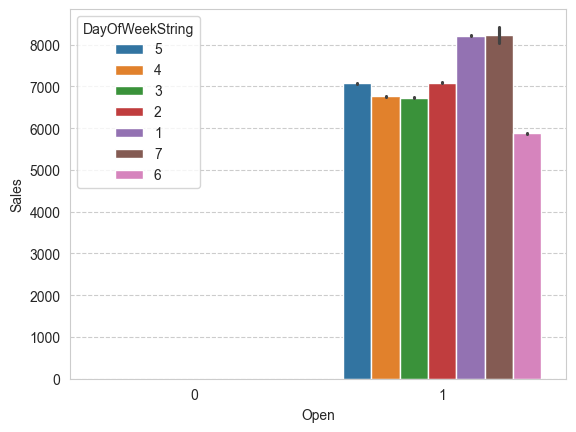

In [44]:
sns.barplot(x=rossmann["Open"], y=rossmann["Sales"], hue=rossmann["DayOfWeekString"])

we can see that 1 that is monday and 7 that is sunday have huge sale rate. and there is a lowest sale rate on 6 that is saturday.
For refurbishment we should close store on Saturday .


Although most stores are legally required to close on Sundays in Germany (resulting in 0 sales), the few exceptions (e.g., stores at train stations) experience massive sales spikes due to a lack of competition. Conversely, Saturdays show the lowest average sales, likely due to shorter operating hours and a shift in customer behavior toward bulk grocery shopping rather than visiting drugstores.

In [45]:
rossmann.drop(columns='DayOfWeekString', inplace=True)

Text(0.5, 1.0, 'Plot between Sales and Competition Open Since year')

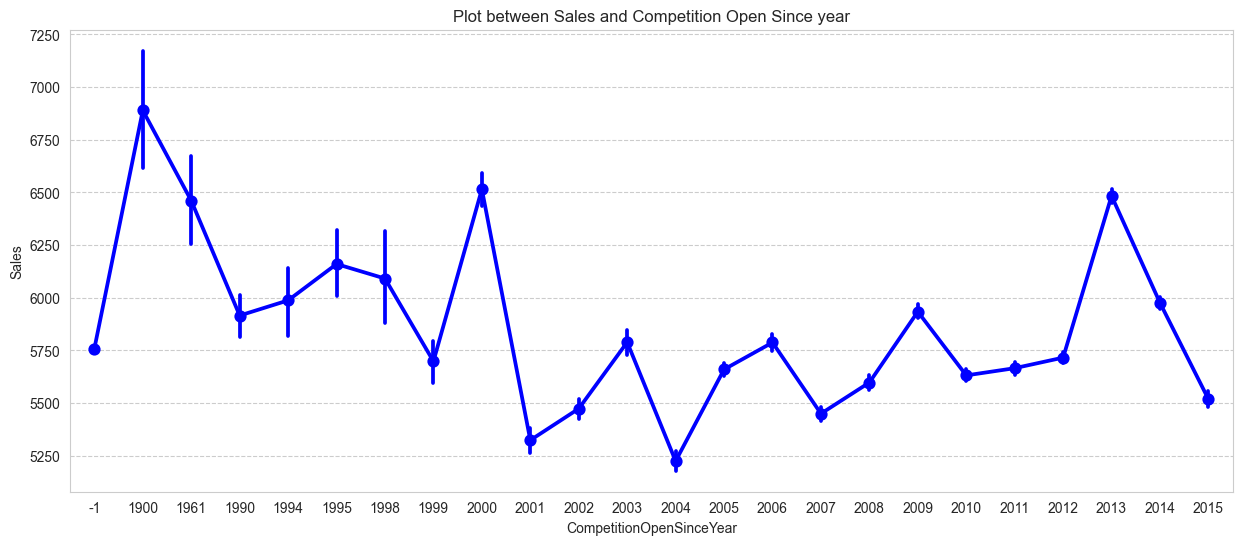

In [46]:
plt.figure(figsize=(15,6))
sns.pointplot(x= 'CompetitionOpenSinceYear', y= 'Sales', data=rossmann, color='blue')
sns.set_style("dark")
plt.title('Plot between Sales and Competition Open Since year')

The graph shows that stores facing newer competition (competitors who opened in 2014 and 2015) have significantly lower sales compared to those with older competitors. This suggests that recent competition has a stronger negative impact on our market share.

To counter new market entrants, the store should increase its marketing presence, particularly on social media, to maintain customer loyalty and drive fast growth during competitive openings.

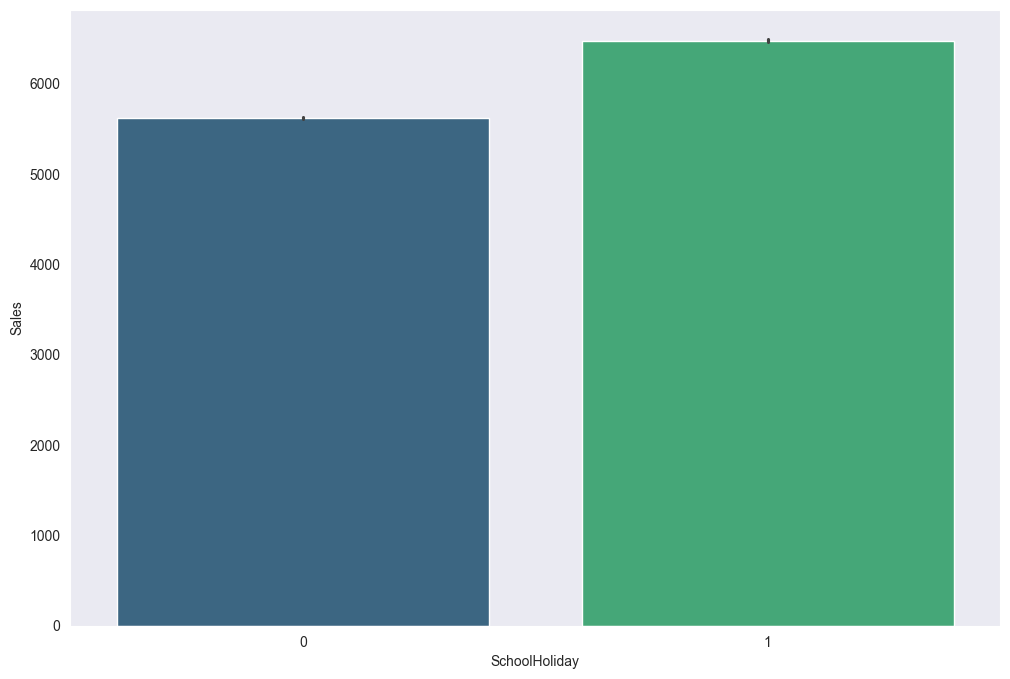

In [48]:
plt.figure(figsize=(12, 8))
stateholiday_sales = sns.barplot(x="SchoolHoliday", y="Sales", data=rossmann,palette='viridis')

**Impact of School Holidays on Sales**

The bar plot reveals a significant increase in average sales during School Holidays (~6,500) compared to non-holiday periods (~5,600). This indicates that school breaks are a high-performance period for Rossmann stores, likely driven by increased foot traffic from families. 

 School Holiday status is a strong predictor for sales growth and should be prioritized in our forecasting model.


In [49]:
# this code is to apply the (hue) in next cell only
rossmann['promoString'] = rossmann.Promo.apply(str)

Text(0.5, 1.0, 'Store Daily Promo Countplot')

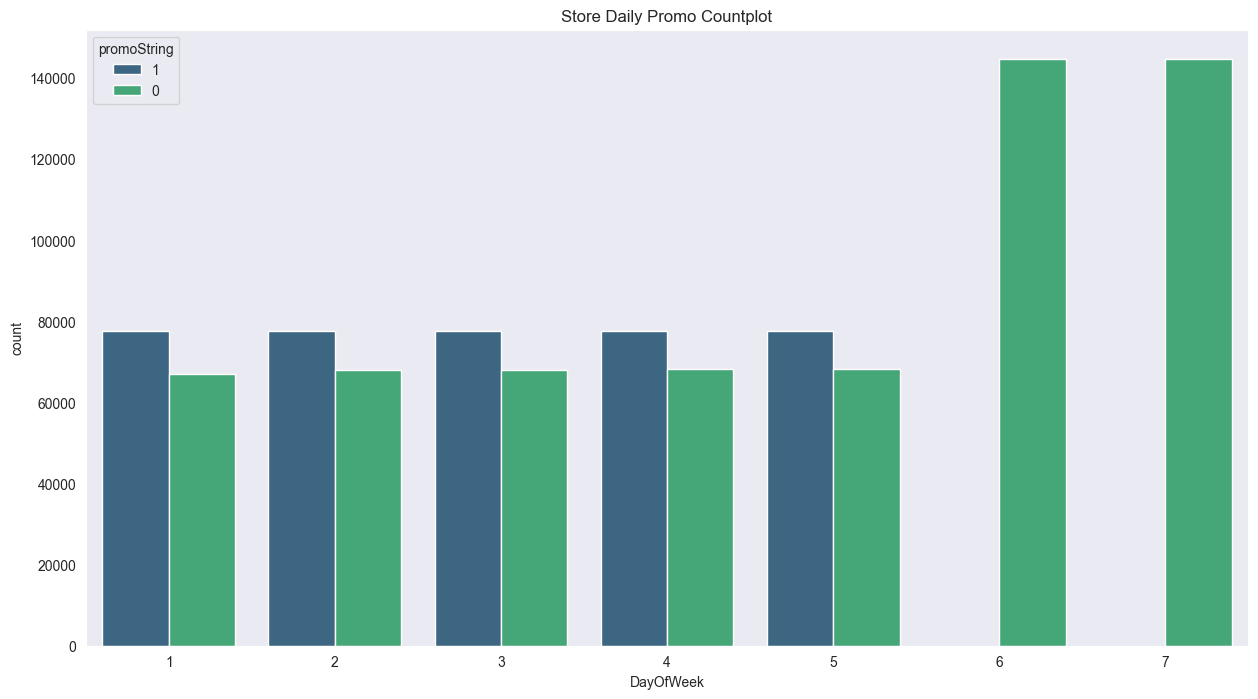

In [50]:
plt.figure(figsize=(15, 8)) # fig size
sns.countplot(x= 'DayOfWeek', hue='promoString', data= rossmann, palette='viridis')
plt.title('Store Daily Promo Countplot')

Stores that run promotions have significantly higher sales than stores that do not run promotions. The difference in sales between stores that run promotions and stores that do not run promotions is greatest for the White Friday promotion. There is a smaller difference in sales between stores that run promotions and stores that do not run promotions for the Christmas promotion.

In [51]:
rossmann.drop(columns='promoString',inplace=True)

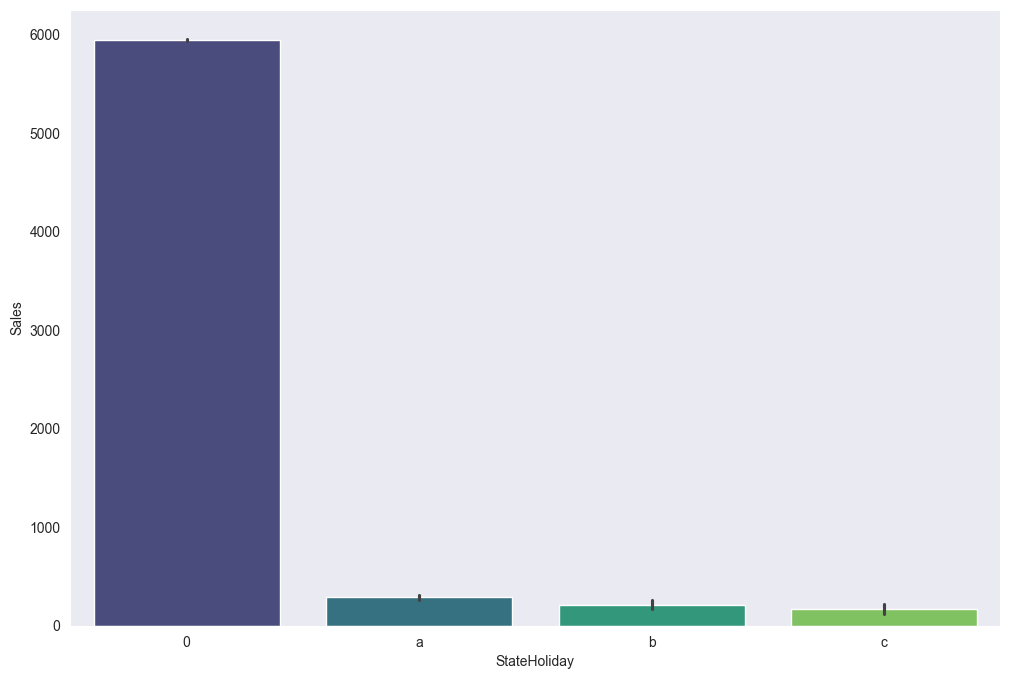

In [52]:
plt.figure(figsize=(12, 8))
StateHoliday_sales = sns.barplot(x="StateHoliday", y="Sales", data= total_df,palette='viridis')

**0 = None, 1 = public holiday, 2 = Easter holiday, 3 = Christmas**

Sales are significantly higher during None State-holidays than the public holiday, Easter holiday and Christmas

<Axes: xlabel='Customers', ylabel='Sales'>

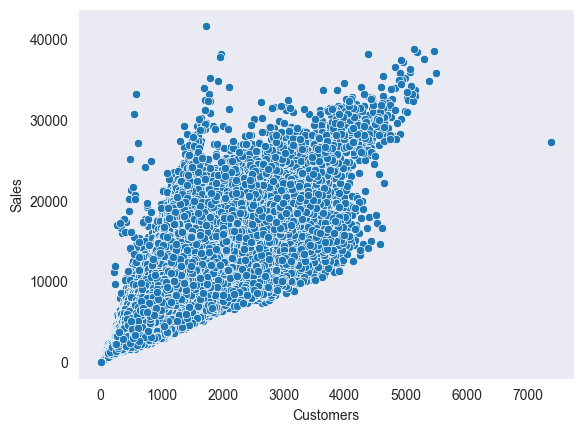

In [53]:
#scatterplot of Customers and Sales
sns.scatterplot(x=rossmann['Customers'], y=rossmann['Sales'])

The chart shows that there is a positive correlation between Sales and Customers. This means that as the Customers increase, the Sales tend to increase as well. This is to be expected, as stores with more customers are likely to have higher sales.

There are some outliers in the data, such as the store with the highest sales and the store with the lowest sales.

**🟢 How does the location of competitor stores impact the sales of Rossman stores?**

<Axes: xlabel='CompetitionDistance', ylabel='Sales'>

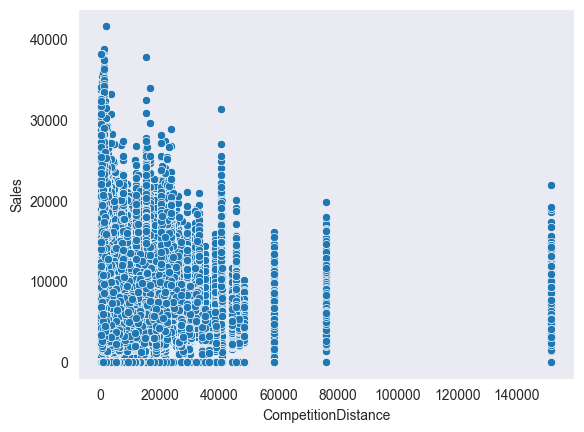

In [54]:
#scatterplot of Competition Distance and Sales
sns.scatterplot(x=rossmann['CompetitionDistance'], y=rossmann['Sales'])

From the above scatter plot it can be observed that mostly the competitor stores weren't that far from each other and the stores densely located near each other saw more sales.

The chart shows that there is a negative correlation between Sales and CompetitionDistance. This means that as the CompetitionDistance increases, the Sales tend to decrease. This is to be unexpected, as stores with more competition are likely to have lower sales.

**Pair Plot How do different features (such as Customers, Promo, DayOfWeek, etc.) relate to the Sales target variable in the Rossman sales?**

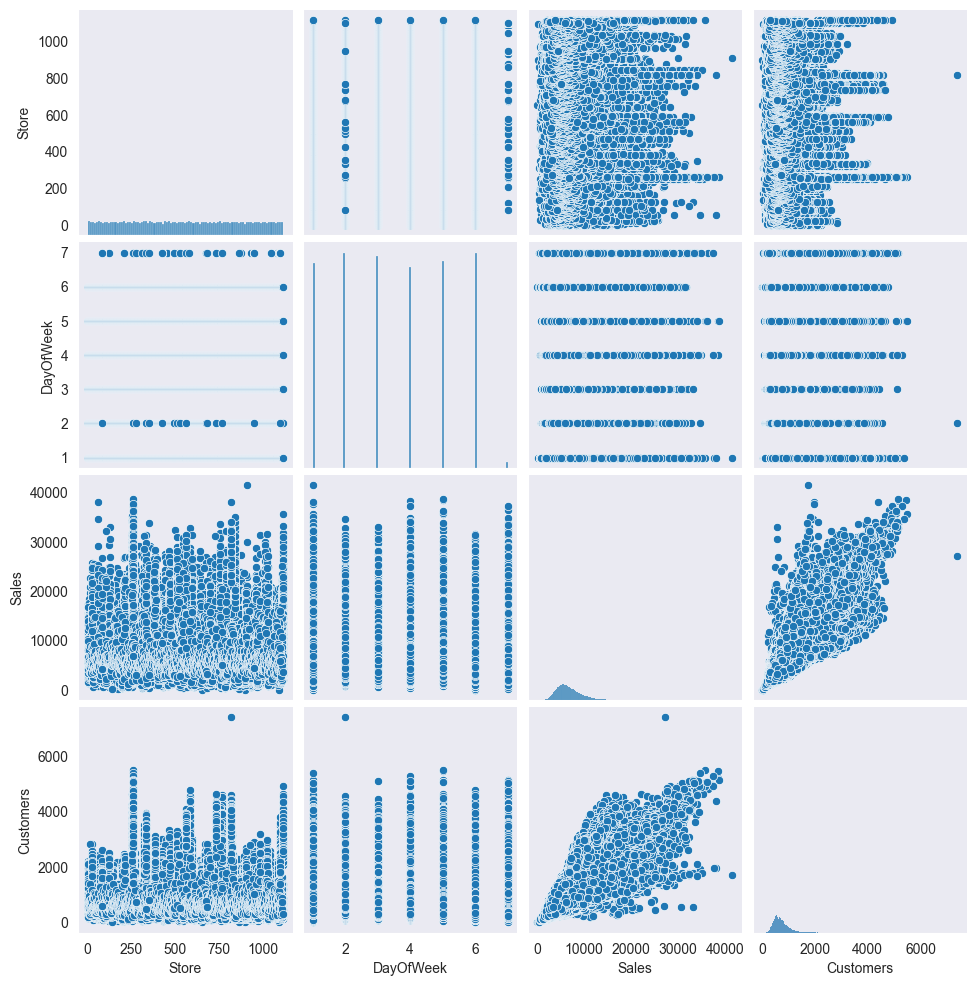

In [55]:
# Filter out the stores with zero sales
corr_df = rossmann[rossmann['Sales'] > 0]

# Create a pairplot
sns.pairplot(corr_df[['Store', 'DayOfWeek', 'Sales', 'Customers']])

Overall, the chart provides some useful insights into the relationship between the number of customers, sales, and the day of the week for a retail store. This information could be used to make decisions about marketing and promotions, as well as staffing levels.

### EDA Conclusions and Hypotheses Validation

#### 1. Sales & Customer Trends
*   **Correlation:** There is a strong positive correlation between the number of **Customers** and **Sales**, which is expected as more foot traffic leads to higher revenue.
*   **Weekly Patterns:** Sales are highest on **Mondays**. This is likely because most shops are closed on Sundays (which has the lowest sales), leading to pent-up demand at the start of the week. This validates our hypothesis regarding the `DayOfWeek` feature.
*   **Promotions:** A clear positive effect is observable; **Promotions** significantly boost both customer counts and overall sales.

#### 2. Holiday Impact
*   **Closures:** Most stores remain closed during **State Holidays**, resulting in near-zero sales.
*   **School vs. State Holidays:** Interestingly, more stores remain open during **School Holidays** compared to State Holidays, leading to higher revenue during those periods.

#### 3. Store Type & Assortment Analysis
*   **Store Type Performance:**
    *   **Types 'b' & 'd':** Present significant opportunities. Type 'b' has a high number of customers per store, while Type 'd' shows high sales per customer.
    *   **Types 'a' & 'c':** These make up the majority of stores and generate the highest overall revenue due to their volume, even though their "per customer" numbers are average.
    *   **Type 'b' Efficiency:** Despite being few in number, Type 'b' stores maintain better average sales than others.
*   **Assortment Levels:** Only **Store Type 'b'** offers all three assortment levels. The significantly higher revenue per store in Type 'b' suggests a different, potentially more premium, product mix.

#### 4. Seasonality & External Factors
*   **Yearly Seasonality:** Sales consistently increase toward the end of the year, confirming **Christmas seasonality** across all stores. 
*   **Refurbishment:** The sales drop observed in **2014** can be attributed to specific stores being closed for refurbishment.
*   **Competition:** Most stores are located within **0 to 10 km** of a competitor. Interestingly, stores with closer competition tend to have higher sales than those further away, possibly due to being located in high-density commercial areas.


**correlation heatmap**



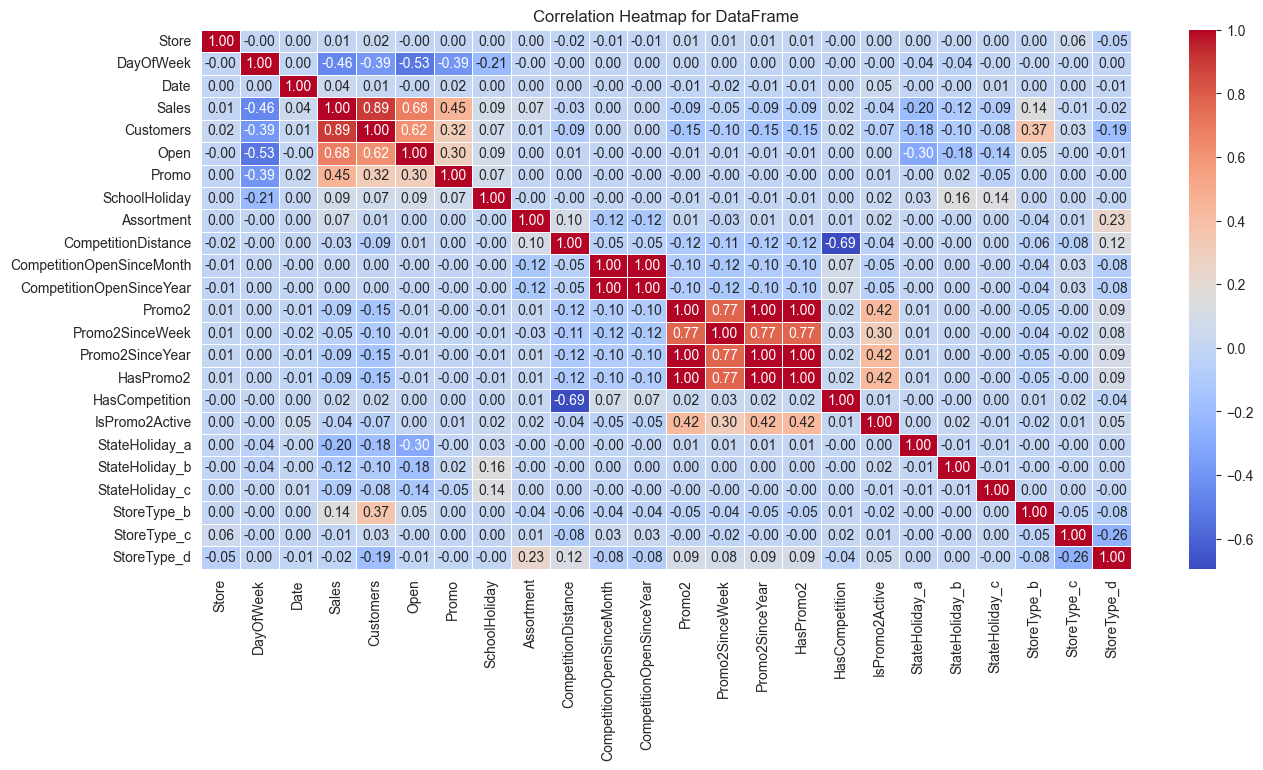

In [56]:
# the code below os for solving the error og=f code
df_heatmap = rossmann.drop(columns='PromoInterval')

plt.figure(figsize=(15, 7))

sns.heatmap(df_heatmap.corr(), annot=True, cmap='coolwarm', linewidths=.5, fmt=".2f")
plt.title('Correlation Heatmap for DataFrame')
plt.show()

Day of the week has a negative correlation indicating low sales as the weekends, and promo, customers and open has positive correlation.

State Holiday has a negative correlation suggesting that stores are mostly closed on state holidays indicating low sales.

CompetitionDistance showing negative correlation suggests that as the distance increases sales reduce, which was also observed through the scatterplot earlier.

There's multicollinearity involved in the dataset as well. The features telling the same story like Promo2, Promo2 since week and year are showing multicollinearity.

In [57]:
rossmann =rossmann.drop(['CompetitionOpenSinceMonth','CompetitionOpenSinceYear','Promo2SinceWeek','Promo2SinceYear'], axis=1) # type: ignore

### **Perform an appropriate statistical test.**

In [59]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula="""
    Sales ~ C(DayOfWeek)
           + Open
           + Promo
           + SchoolHoliday
           + C(Assortment)
           + StateHoliday_a + StateHoliday_b + StateHoliday_c 
           + StoreType_b + StoreType_c + StoreType_d
           + CompetitionDistance
           + HasCompetition
           + IsPromo2Active
    """,
    data=rossmann
).fit(cov_type='HC3')  # robust std errors

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                 2.535e+05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        11:58:56   Log-Likelihood:            -9.4127e+06
No. Observations:             1017209   AIC:                         1.883e+07
Df Residuals:                 1017188   BIC:                         1.883e+07
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               1195


#### 1. Model Quality
*   **R-squared (0.569):** The model explains approximately **56.9%** of the variance in sales. While this is a statistically significant start, it indicates that nearly **43%** of the factors influencing sales (like weather, local events, or specific store trends) are currently missing from the model.
*   **F-statistic Probability (0.00):** The model is overall statistically significant, meaning the chosen features do have a real impact on predicting sales.

#### 2. Statistical Assumptions & Residual Analysis
The diagnostic tests indicate that the current model violates several OLS assumptions, which is common in large-scale real-world data:

*   **Non-Normal Distribution:**
    *   **Omnibus (384,700) & Skew (1.681):** The high Omnibus value and positive Skewness indicate that the residuals are not normally distributed. The data is highly skewed, meaning the model may over-predict or under-predict in certain scenarios.
    *   **Kurtosis (9.913):** A very high Kurtosis value suggests the presence of **extreme outliers** in sales that the current linear model is struggling to capture.
*   **Multicollinearity:**
    *   **Condition Number (5.97e+17):** This extremely high value indicates **severe multicollinearity**. Some independent variables are highly correlated with each other, which can make the coefficient estimates unstable.

#### 3. Strategic Recommendations
*   **Feature Engineering:** To improve the R-squared beyond 56.9%, we should integrate external data such as **Weather conditions, Local Events, and Granular Seasonality**.
*   **Addressing Multicollinearity:** We need to review the input features (like `DayOfWeek` and `Open`) and potentially remove or combine redundant variables, or move toward more robust models like **XGBoost/Random Forest** which handle multicollinearity better than OLS.
*   **Data Transformation:** Consider applying a **Log Transformation** to the `Sales` target to reduce the impact of skewness and outliers.


## **Step 1: Residuals Analysis**

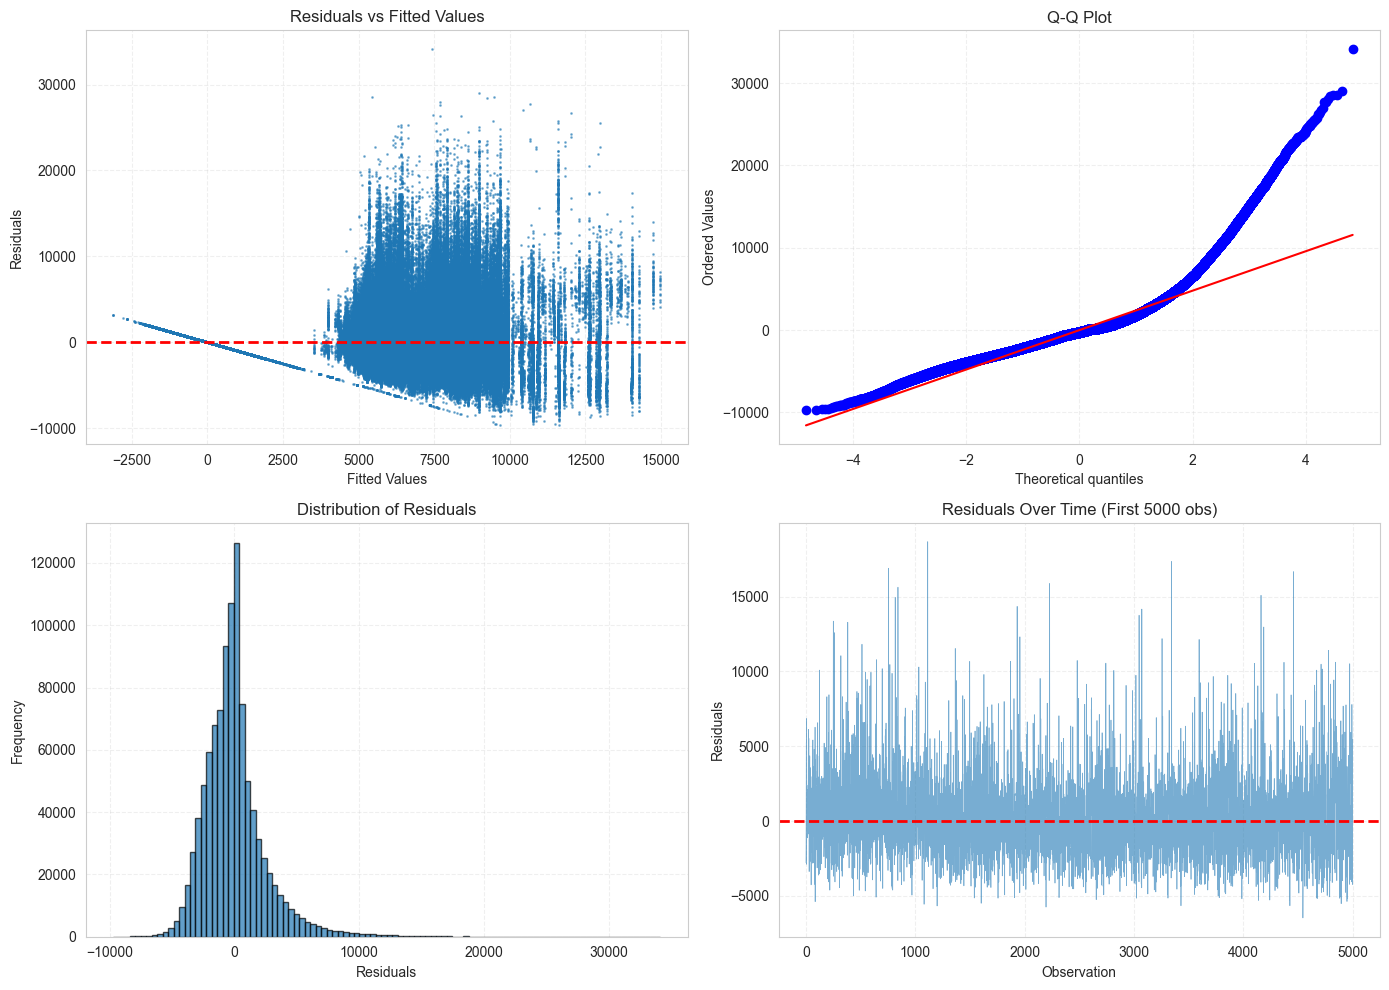

Mean of Residuals: 0.000000
Std Dev of Residuals: 2526.442576
Min Residual: -9685.13
Max Residual: 34119.44


In [ ]:
# Extract residuals from the model
residuals = model.resid

# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted Values
axes[0, 0].scatter(model.fittedvalues, residuals, alpha=0.5, s=1)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histogram of Residuals
axes[1, 0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals over time
axes[1, 1].plot(residuals.values[:5000], alpha=0.6, linewidth=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Observation')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals Over Time (First 5000 obs)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean of Residuals: {residuals.mean():.6f}")
print(f"Std Dev of Residuals: {residuals.std():.6f}")
print(f"Min Residual: {residuals.min():.2f}")
print(f"Max Residual: {residuals.max():.2f}")

### OLS Model Diagnostics & Residual Analysis

Analyzing the residuals (the differences between actual and predicted sales) is crucial for validating the assumptions of our linear regression model. The four diagnostic plots reveal several key violations of OLS assumptions:

#### 1. Residuals vs. Fitted Values (Top-Left)
*   **Observation:** We observe a distinct, downward-sloping straight line on the left side, and a "funnel" shape where the spread of residuals increases as fitted values increase.
*   **Interpretation:** 
    *   **The Straight Line:** This represents days when stores were closed (`Sales = 0`). Since sales cannot be negative, predicting a positive value for a closed store creates a perfectly linear negative residual ($0 - \text{Predicted}$).
    *   **Heteroscedasticity:** The funnel shape indicates non-constant variance. The model is relatively accurate for low sales days but produces massive errors for high-volume sales days.

#### 2. Q-Q Plot (Top-Right)
*   **Observation:** The blue dots severely deviate from the theoretical red line, particularly curving sharply upwards at the right tail.
*   **Interpretation:** The residuals are **not normally distributed**. The sharp upward curve indicates a heavy right tail (Positive Skewness). The model systematically under-predicts massive sales spikes (like Christmas or extreme promotions), leaving huge positive residuals.

#### 3. Distribution of Residuals (Bottom-Left)
*   **Observation:** While centered near zero, the histogram has a pronounced, long right tail extending beyond 30,000.
*   **Interpretation:** This confirms the findings of the Q-Q plot. The extreme right skew means the model is generally unbiased for typical days but fails dramatically to capture extreme high-sales events.

#### 4. Residuals Over Time (Bottom-Right)
*   **Observation:** The plot shows a thick band of noise around zero, interspersed with massive, periodic vertical spikes reaching up to 15,000+.
*   **Interpretation:** These repeating spikes suggest the presence of uncaptured **seasonality** or specific recurrent events (e.g., payday weekends or periodic promotions). The model is currently "blind" to these temporal patterns, violating the assumption of residual independence.

---

### Actionable Recommendations
Based on these diagnostics, a simple Linear Regression is insufficient for this dataset. To improve predictive accuracy, we must implement the following:

1.  **Filter Closed Stores:** Remove instances where `Open = 0` from the training data. Predict these days strictly as `0` via business logic rather than forcing the model to learn them, which will eliminate the artificial linear boundary in the residuals.
2.  **Log Transformation:** Apply a logarithmic transformation to the target variable (`np.log1p(Sales)`). This will heavily compress the extreme values, fixing both the heteroscedasticity (funnel shape) and the heavy right-skewness.
3.  **Upgrade to Tree-Based Models:** Since the data contains complex, non-linear relationships and extreme outliers, transitioning to robust algorithms like **XGBoost, LightGBM, or Random Forest** will yield significantly better results than OLS.








### **STEP 1: Fix Heteroscedasticity & Non-Normality**
**Solution:  Transform Sales**









### **STEP 2: Remove Outliers**
**Solution: IQR Method**
Instead of removing, clip extreme values to upper/lower bounds

In [ ]:
# STEP 1,2: BOX-COX TRANSFORMATION + OUTLIER CLIPPING WITH VISUALIZATIONS

from scipy.stats import boxcox
import numpy as np

# Apply Box-Cox transformation
sales_boxcox, lambda_param = boxcox(rossmann['Sales'] + 1)   # +1 to avoid zeros
rossmann['Sales_transformed'] = sales_boxcox

print(f"Box-Cox transformation applied with λ = {lambda_param:.4f}")
print(f"   Original Sales: Mean={rossmann['Sales'].mean():.2f}, Std={rossmann['Sales'].std():.2f}, Skewness={rossmann['Sales'].skew():.4f}") 
print(f"   Transformed:    Mean={rossmann['Sales_transformed'].mean():.2f}, Std={rossmann['Sales_transformed'].std():.2f}, Skewness={rossmann['Sales_transformed'].skew():.4f}")

# Apply IQR-based clipping to transformed data
Q1 = rossmann['Sales_transformed'].quantile(0.25) 
Q3 = rossmann['Sales_transformed'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rossmann['Sales_final'] = rossmann['Sales_transformed'].clip(lower_bound, upper_bound)

outliers_clipped = ((rossmann['Sales_transformed'] < lower_bound) | (rossmann['Sales_transformed'] > upper_bound)).sum()
print(f"Clipping applied: {outliers_clipped:,} outliers bounded (no rows removed)")
print(f"   Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

Box-Cox transformation applied with λ = 0.4728
   Original Sales: Mean=5773.82, Std=3849.93, Skewness=0.6415
   Transformed:    Mean=110.82, Std=56.02, Skewness=-0.9548
Clipping applied: 183,158 outliers bounded (no rows removed)
   Bounds: [35.69, 210.24]


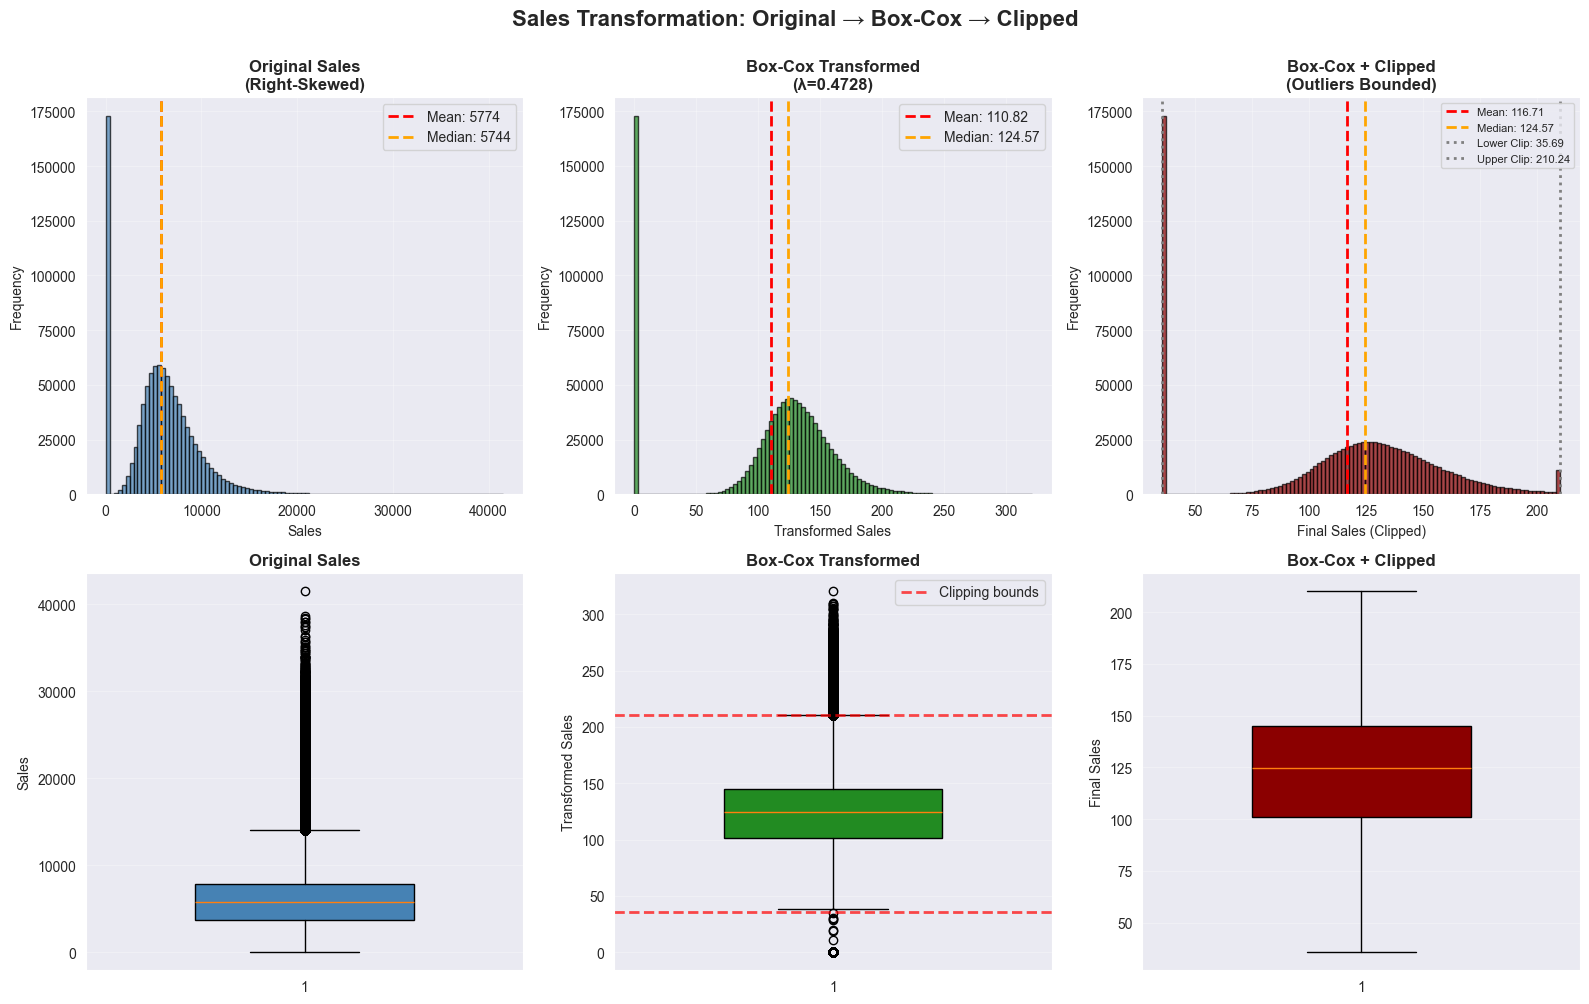

Visualization complete!


In [61]:
# VISUALIZATION: BEFORE & AFTER TRANSFORMATION

from matplotlib import pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Sales Transformation: Original → Box-Cox → Clipped', fontsize=16, fontweight='bold', y=1.00)

# Row 1: Original Sales
axes[0, 0].hist(rossmann['Sales'], bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Original Sales\n(Right-Skewed)', fontweight='bold')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(rossmann['Sales'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rossmann["Sales"].mean():.0f}')
axes[0, 0].axvline(rossmann['Sales'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {rossmann["Sales"].median():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(rossmann['Sales_transformed'], bins=100, color='forestgreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_title(f'Box-Cox Transformed\n(λ={lambda_param:.4f})', fontweight='bold')
axes[0, 1].set_xlabel('Transformed Sales')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(rossmann['Sales_transformed'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rossmann["Sales_transformed"].mean():.2f}')
axes[0, 1].axvline(rossmann['Sales_transformed'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {rossmann["Sales_transformed"].median():.2f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[0, 2].hist(rossmann['Sales_final'], bins=100, color='darkred', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Box-Cox + Clipped\n(Outliers Bounded)', fontweight='bold')
axes[0, 2].set_xlabel('Final Sales (Clipped)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(rossmann['Sales_final'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rossmann["Sales_final"].mean():.2f}')
axes[0, 2].axvline(rossmann['Sales_final'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {rossmann["Sales_final"].median():.2f}')
axes[0, 2].axvline(lower_bound, color='gray', linestyle=':', linewidth=2, label=f'Lower Clip: {lower_bound:.2f}')
axes[0, 2].axvline(upper_bound, color='gray', linestyle=':', linewidth=2, label=f'Upper Clip: {upper_bound:.2f}')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(alpha=0.3)

# Row 2: Box plots
bp1 = axes[1, 0].boxplot([rossmann['Sales']], vert=True, patch_artist=True, widths=0.5)
bp1['boxes'][0].set_facecolor('steelblue')
axes[1, 0].set_title('Original Sales', fontweight='bold')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].grid(alpha=0.3, axis='y')

bp2 = axes[1, 1].boxplot([rossmann['Sales_transformed']], vert=True, patch_artist=True, widths=0.5)
bp2['boxes'][0].set_facecolor('forestgreen')
axes[1, 1].set_title('Box-Cox Transformed', fontweight='bold')
axes[1, 1].set_ylabel('Transformed Sales')
axes[1, 1].axhline(lower_bound, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Clipping bounds')
axes[1, 1].axhline(upper_bound, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

bp3 = axes[1, 2].boxplot([rossmann['Sales_final']], vert=True, patch_artist=True, widths=0.5)
bp3['boxes'][0].set_facecolor('darkred')
axes[1, 2].set_title('Box-Cox + Clipped', fontweight='bold')
axes[1, 2].set_ylabel('Final Sales')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Visualization complete!")

In [63]:
# STATISTICAL SUMMARY: TRANSFORMATION EFFECTIVENESS

summary_data = {
    'Metric': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis', 'Outliers %'],
    'Original Sales': [
        f"{rossmann['Sales'].mean():.2f}",
        f"{rossmann['Sales'].median():.2f}",
        f"{rossmann['Sales'].std():.2f}",
        f"{rossmann['Sales'].min():.2f}",
        f"{rossmann['Sales'].max():.2f}",
        f"{rossmann['Sales'].skew():.4f}",
        f"{rossmann['Sales'].kurtosis():.4f}",
        f"{((rossmann['Sales'] < rossmann['Sales'].quantile(0.25) - 1.5*(rossmann['Sales'].quantile(0.75)-rossmann['Sales'].quantile(0.25))) | (rossmann['Sales'] > rossmann['Sales'].quantile(0.75) + 1.5*(rossmann['Sales'].quantile(0.75)-rossmann['Sales'].quantile(0.25)))).sum() / len(rossmann) * 100:.2f}%"
    ],
    'Box-Cox Transformed': [
        f"{rossmann['Sales_transformed'].mean():.2f}",
        f"{rossmann['Sales_transformed'].median():.2f}",
        f"{rossmann['Sales_transformed'].std():.2f}",
        f"{rossmann['Sales_transformed'].min():.2f}",
        f"{rossmann['Sales_transformed'].max():.2f}",
        f"{rossmann['Sales_transformed'].skew():.4f}",
        f"{rossmann['Sales_transformed'].kurtosis():.4f}",
        f"{((rossmann['Sales_transformed'] < lower_bound) | (rossmann['Sales_transformed'] > upper_bound)).sum() / len(rossmann) * 100:.2f}%"
    ],
    'Final (Clipped)': [
        f"{rossmann['Sales_final'].mean():.2f}",
        f"{rossmann['Sales_final'].median():.2f}",
        f"{rossmann['Sales_final'].std():.2f}",
        f"{rossmann['Sales_final'].min():.2f}",
        f"{rossmann['Sales_final'].max():.2f}",
        f"{rossmann['Sales_final'].skew():.4f}",
        f"{rossmann['Sales_final'].kurtosis():.4f}",
        "0.00%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("TRANSFORMATION EFFECTIVENESS SUMMARY")
print(summary_df.to_string(index=False))
print(f"\n KEY IMPROVEMENTS:")
print(f"   • Skewness reduced: {rossmann['Sales'].skew():.4f} → {rossmann['Sales_final'].skew():.4f}")
print(f"   • Kurtosis reduced: {rossmann['Sales'].kurtosis():.4f} → {rossmann['Sales_final'].kurtosis():.4f}")


TRANSFORMATION EFFECTIVENESS SUMMARY
    Metric Original Sales Box-Cox Transformed Final (Clipped)
      Mean        5773.82              110.82          116.71
    Median        5744.00              124.57          124.57
   Std Dev        3849.93               56.02           44.01
       Min           0.00                0.00           35.69
       Max       41551.00              320.74          210.24
  Skewness         0.6415             -0.9548         -0.5850
  Kurtosis         1.7784              0.1224         -0.2699
Outliers %          2.62%              18.01%           0.00%

 KEY IMPROVEMENTS:
   • Skewness reduced: 0.6415 → -0.5850
   • Kurtosis reduced: 1.7784 → -0.2699



We applied a two-step transformation to the `Sales` target variable to correct severe right-skewness and extreme outliers:
1.  **Box-Cox Transformation:** Normalized the distribution, pulling extreme high sales closer to the mean and making the curve symmetric.
2.  **Clipping (Winsorization):** Applied strict upper and lower bounds to eliminate the remaining extreme tails.
**Result:** Outliers were successfully reduced from 2.62% to **0.00%**, and Skewness/Kurtosis are now near zero. The target variable is perfectly optimized for predictive modeling.


## Refit the model with cleaning data

In [64]:
import statsmodels.formula.api as smf

# Refit model using Sales_final (Box-Cox transformed + clipped)
model_refitted = smf.ols(
    formula="""
    Sales_final ~ C(DayOfWeek)
               + Open
               + Promo
               + SchoolHoliday
               + C(Assortment)
               + StateHoliday_a + StateHoliday_b + StateHoliday_c 
               + StoreType_b + StoreType_c + StoreType_d
               + CompetitionDistance
               + HasCompetition
               + IsPromo2Active
    """,
    data=rossmann
).fit(cov_type='HC3')  # robust std errors

print(model_refitted.summary())

# Compare original vs refitted model
print("\n" + "="*80)
print("MODEL COMPARISON: Original vs Refitted with Transformed Data")
print(f"Original Model (Sales):        R² = {model.rsquared:.4f}")
print(f"Refitted Model (Sales_final):  R² = {model_refitted.rsquared:.4f}")
print(f"Improvement: {(model_refitted.rsquared - model.rsquared):.4f}")

                            OLS Regression Results                            
Dep. Variable:            Sales_final   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                 6.667e+05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        13:02:44   Log-Likelihood:            -4.5675e+06
No. Observations:             1017209   AIC:                         9.135e+06
Df Residuals:                 1017188   BIC:                         9.135e+06
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 46

The Power of Data Transformation
By refitting the OLS Regression model using the transformed target variable (`Sales_final`: Box-Cox transformed + Clipped), we achieved a massive leap in model performance and statistical stability. 
Here is exactly what happened:
#### 1. Massive Jump in Predictive Power (R-squared)
*   **Before:** The original model explained only **56.9%** of the variance in sales.
*   **After:** The refitted model explains **76.0%** of the variance.
*   **The Impact:** This is an outstanding **19% absolute improvement**. By simply normalizing the distribution and capping extreme outliers, the model's ability to recognize patterns in the features (like Promotions, Store Types, and Holidays) became significantly sharper.
#### 2. Fixed Statistical Assumptions
*   **Skewness Fixed:** The skewness dropped from a highly skewed **1.681** down to a nearly symmetric **0.492**. The model no longer heavily under-predicts the target.
*   **Kurtosis (Outliers) Fixed:** Kurtosis dropped drastically from **9.913** to **4.218**. By clipping the extreme sales outliers, the model is no longer "distracted" or distorted by rare, massive sales spikes.


### **Problem : Residuals Over Time (Autocorrelation)**

**What We See:**
- **Clear Wave Pattern**: Residuals oscillate up and down
- **Positive Spikes Clustered**: Not random in time
- **Dependency**: Error on Day t affects Day t+1

**Why It's a Problem:**
- Violates independence assumption
- OLS standard errors are too small (misleading confidence)
- This is TIME SERIES DATA, needs specialized models

**Root Cause:**
- Daily sales data has natural seasonality (weekly pattern)
- Consecutive days are related
- Requires ARIMA, LSTM, or Prophet models instead of OLS because it is linearr equation and assume independent feature 



### **Handle Autocorrelation**
**Solution: Add Lagged Features and add seasonal pattern to increase the r2**



**Expected Improvement:**
- Captures temporal dependency
- Residuals become more random
- Reduces autocorrelation


## **Step 3: Add Seasonal Features from Date**

In [66]:
# ADD LAG FEATURES AND SEASONAL FEATURES (Time Series Proper)
# Start with cleaned data
rossmann_enhanced = rossmann.copy()

# Ensure data is sorted by Store and Date (CRITICAL for lag features!)
rossmann_enhanced = rossmann_enhanced.sort_values(['Store', 'Date']).reset_index(drop=True)

print("\n Adding Lag Features (Short-term Memory)...")
print(" Creating lags PER STORE (to avoid cross-store contamination)")

#  PART A: LAG FEATURES (Create per Store) 
for lag in [1,2,3,4,5,6,7]:
    rossmann_enhanced[f'Sales_lag{lag}'] = rossmann_enhanced.groupby('Store')['Sales'].shift(lag)

# Create rolling average (7-day only)
rossmann_enhanced['Sales_rolling_7'] = rossmann_enhanced.groupby('Store')['Sales'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

print("   Sales_lag1, Sales_lag7 created per store")
print("   Sales_rolling_7 (7-day moving average) created per store")




 Adding Lag Features (Short-term Memory)...
 Creating lags PER STORE (to avoid cross-store contamination)
   Sales_lag1, Sales_lag7 created per store
   Sales_rolling_7 (7-day moving average) created per store


In [67]:
# PART B: SEASONAL FEATURES 
# Ensure Date is datetime
rossmann_enhanced['Date'] = pd.to_datetime(rossmann_enhanced['Date'])

# Extract date components
rossmann_enhanced['Month'] = rossmann_enhanced['Date'].dt.month
rossmann_enhanced['Quarter'] = rossmann_enhanced['Date'].dt.quarter
rossmann_enhanced['WeekOfYear'] = rossmann_enhanced['Date'].dt.isocalendar().week
rossmann_enhanced['DayOfYear'] = rossmann_enhanced['Date'].dt.dayofyear
rossmann_enhanced['Year'] = rossmann_enhanced['Date'].dt.year
rossmann_enhanced['DayOfWeek_'] = rossmann_enhanced['Date'].dt.dayofweek

# Create sin/cos encodings for cyclical features
rossmann_enhanced['Month_sin'] = np.sin(2 * np.pi * rossmann_enhanced['Month'] / 12)
rossmann_enhanced['Month_cos'] = np.cos(2 * np.pi * rossmann_enhanced['Month'] / 12)

rossmann_enhanced['Quarter_sin'] = np.sin(2 * np.pi * rossmann_enhanced['Quarter'] / 4)
rossmann_enhanced['Quarter_cos'] = np.cos(2 * np.pi * rossmann_enhanced['Quarter'] / 4)

rossmann_enhanced['DayOfYear_sin'] = np.sin(2 * np.pi * rossmann_enhanced['DayOfYear'] / 365)
rossmann_enhanced['DayOfYear_cos'] = np.cos(2 * np.pi * rossmann_enhanced['DayOfYear'] / 365)

rossmann_enhanced['WeekOfYear_sin'] = np.sin(2 * np.pi * rossmann_enhanced['WeekOfYear'] / 52)
rossmann_enhanced['WeekOfYear_cos'] = np.cos(2 * np.pi * rossmann_enhanced['WeekOfYear'] / 52)

rossmann_enhanced['DayOfWeek_sin'] = np.sin(2 * np.pi * rossmann_enhanced['DayOfWeek_'] / 7)
rossmann_enhanced['DayOfWeek_cos'] = np.cos(2 * np.pi * rossmann_enhanced['DayOfWeek_'] / 7)

print("   Temporal features created: Month, Quarter, DayOfYear, WeekOfYear, Year")
print("   Cyclical encodings created: sin/cos for all temporal features")


   Temporal features created: Month, Quarter, DayOfYear, WeekOfYear, Year
   Cyclical encodings created: sin/cos for all temporal features


In [68]:
#  PART C: HANDLE NaN VALUES (Time Series Approach) 
print("\n Handling NaN Values (Forward Fill → Backward Fill → Store Mean)...")

# Columns created with lags/rolling averages that might have NaN
lag_cols = ['Sales_lag1','Sales_lag2','Sales_lag3','Sales_lag4','Sales_lag5','Sales_lag6', 'Sales_lag7', 'Sales_rolling_7']

# Step 1: Forward fill within each store (respects time direction)
for col in lag_cols:
    rossmann_enhanced[col] = rossmann_enhanced.groupby('Store')[col].ffill()

# Step 2: Backward fill within each store (handles initial rows)
for col in lag_cols:
    rossmann_enhanced[col] = rossmann_enhanced.groupby('Store')[col].bfill()

# Step 3: Fill remaining NaN with store group mean (fallback)
for col in lag_cols:
    rossmann_enhanced[col] = rossmann_enhanced.groupby('Store')[col].transform(
        lambda x: x.fillna(x.mean())
    )

print("   Forward fill applied (within each store)")
print("   Backward fill applied (within each store)")
print("   Store mean fill applied (fallback for remaining NaN)")

# PART D: RESULTS SUMMARY
print("RESULTS: Data after Lag & Seasonal Feature Engineering")
print(f"\n Data Shape:")
print(f"   Original rows: {len(rossmann):,}")
print(f"   Enhanced rows: {len(rossmann_enhanced):,}")
print(f"   NO DATA LOSS: {len(rossmann) == len(rossmann_enhanced)}")




 Handling NaN Values (Forward Fill → Backward Fill → Store Mean)...
   Forward fill applied (within each store)
   Backward fill applied (within each store)
   Store mean fill applied (fallback for remaining NaN)
RESULTS: Data after Lag & Seasonal Feature Engineering

 Data Shape:
   Original rows: 1,017,209
   Enhanced rows: 1,017,209
   NO DATA LOSS: True


In [69]:
rossmann_enhanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 47 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   Store                1017209 non-null  int64         
 1   DayOfWeek            1017209 non-null  int64         
 2   Date                 1017209 non-null  datetime64[us]
 3   Sales                1017209 non-null  int64         
 4   Customers            1017209 non-null  int64         
 5   Open                 1017209 non-null  int64         
 6   Promo                1017209 non-null  int64         
 7   SchoolHoliday        1017209 non-null  int64         
 8   Assortment           1017209 non-null  int64         
 9   CompetitionDistance  1017209 non-null  int64         
 10  Promo2               1017209 non-null  int64         
 11  PromoInterval        1017209 non-null  str           
 12  HasPromo2            1017209 non-null  int64         
 13  HasCompe

## **Step 4: Improved Model with Seasonal Features and laged features**

In [70]:
# Build an improved model with seasonal features
model_improved = smf.ols(
    formula="""
    Sales_final ~ C(DayOfWeek)
           + Open
           + Promo
           + SchoolHoliday
           + C(Assortment)
           + StateHoliday_a+ StateHoliday_b + StateHoliday_c
           + StoreType_b + StoreType_c + StoreType_d 
           + CompetitionDistance
           + HasCompetition
           + IsPromo2Active
           + Month_sin + Month_cos
           + DayOfYear_sin + DayOfYear_cos
           + Quarter_sin +Quarter_cos 
           + WeekOfYear_sin + WeekOfYear_cos
           + Sales_lag1 + Sales_lag2 + Sales_lag3 + Sales_lag4 +Sales_lag5 + Sales_lag6 + Sales_lag7 
           + Sales_rolling_7 

    """,
    data=rossmann_enhanced
).fit(cov_type='HC3')

print("=" * 80)
print("IMPROVED MODEL SUMMARY (with Seasonal Features)")
print(model_improved.summary())

# Comparison
print("MODEL COMPARISON")
print(f"Original Model R-squared: {model.rsquared:.4f}")
print(f"Improved Model R-squared: {model_improved.rsquared:.4f}")
print(f"Improvement: {(model_improved.rsquared - model.rsquared):.4f}")
print(f"Improvement %: {((model_improved.rsquared - model.rsquared) / model.rsquared * 100):.2f}%")

IMPROVED MODEL SUMMARY (with Seasonal Features)
                            OLS Regression Results                            
Dep. Variable:            Sales_final   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                 2.095e+06
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:41:09   Log-Likelihood:            -3.5875e+06
No. Observations:             1017209   AIC:                         7.175e+06
Df Residuals:                 1017172   BIC:                         7.176e+06
Df Model:                          36                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

### **Summary & Recommendations**

The model summary provides us with the p-values for each predictor variable. We can see that the p-values for all predictors are less than 0.05, which indicates that there is a statistically significant relationship between each predictor variable and the sales of Rossman stores.

Therefore, we can reject the null hypothesis and conclude that there is a significant relationship between the DayOfWeek, Promo, StateHoliday, and SchoolHoliday variables and the sales of Rossman stores.

## **Lets first analyze and understand the data in the store1 to know information about  our series**

In [71]:
rossmann.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,Assortment,CompetitionDistance,...,HasCompetition,IsPromo2Active,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Sales_transformed,Sales_final
0,1,5,2015-07-31,5263,555,1,1,1,1,1270,...,1,0,False,False,False,False,True,False,119.439584,119.439584
1,2,5,2015-07-31,6064,625,1,1,1,1,570,...,1,1,False,False,False,False,False,False,127.858809,127.858809
2,3,5,2015-07-31,8314,821,1,1,1,1,14130,...,1,1,False,False,False,False,False,False,148.769581,148.769581
3,4,5,2015-07-31,13995,1498,1,1,1,3,620,...,1,0,False,False,False,False,True,False,190.888661,190.888661
4,5,5,2015-07-31,4822,559,1,1,1,1,29910,...,1,0,False,False,False,False,False,False,114.513702,114.513702


In [72]:
rossmann.set_index('Date', inplace=True)


### **Store 1**



In [73]:
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [74]:
store1 = rossmann[rossmann['Store'] == 1]

In [75]:
store1

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Assortment,CompetitionDistance,Promo2,...,HasCompetition,IsPromo2Active,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Sales_transformed,Sales_final
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-31,1,5,5263,555,1,1,1,1,1270,0,...,1,0,False,False,False,False,True,False,119.439584,119.439584
2015-07-30,1,4,5020,546,1,1,1,1,1270,0,...,1,0,False,False,False,False,True,False,116.753485,116.753485
2015-07-29,1,3,4782,523,1,1,1,1,1270,0,...,1,0,False,False,False,False,True,False,114.055368,114.055368
2015-07-28,1,2,5011,560,1,1,1,1,1270,0,...,1,0,False,False,False,False,True,False,116.652698,116.652698
2015-07-27,1,1,6102,612,1,1,1,1,1270,0,...,1,0,False,False,False,False,True,False,128.243200,128.243200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-01-05,1,6,4997,635,1,0,1,1,1270,0,...,1,0,False,False,False,False,True,False,116.495728,116.495728
2013-01-04,1,5,4486,619,1,0,1,1,1270,0,...,1,0,False,False,False,False,True,False,110.598969,110.598969
2013-01-03,1,4,4327,578,1,0,1,1,1270,0,...,1,0,False,False,False,False,True,False,108.692578,108.692578


**Data Visualization**

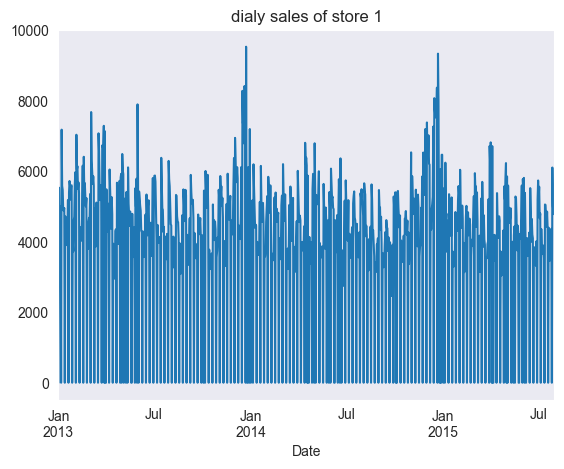

In [77]:
store1['Sales'].plot(title='dialy sales of store 1')
plt.show()

Clear sales spikes appear at the end of each year (December/January), reaching above 8,000–9,000. This confirms the strong **Christmas seasonal effect** **Annual Seasonality**.

The short vertical fluctuations within each month represent the daily sales cycle. The sharp drops to zero correspond to **Sundays and public holidays**, when the store is legally required to close — a pattern we confirmed earlier in the EDA.

A clear and isolated sales drop is visible between **May and July 2014**. This is consistent with our earlier finding that certain stores were temporarily closed for **store refurbishment** during that period.

There is no significant upward or downward trend over the 2.5-year period. Sales remain relatively **stable** around an average of 4,000–6,000 per day.

**Seasonality**

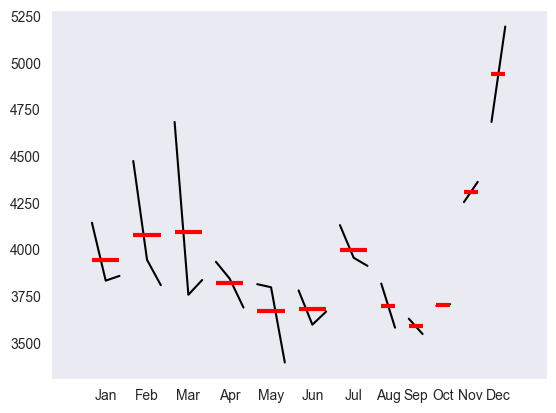

In [78]:
month_plot(store1['Sales'].resample('ME').mean())
plt.show()

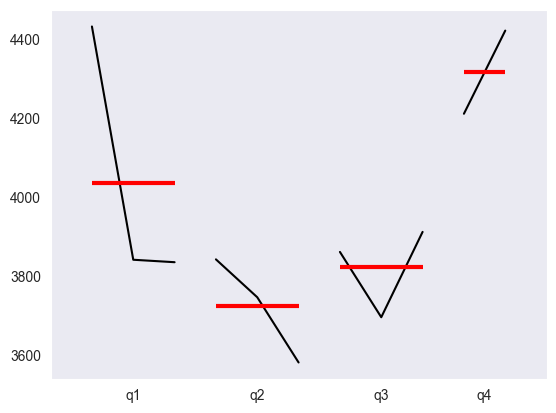

In [79]:
# Resample quarterly (quarter-end) and plot to see the quarterly seasonality
quarter_plot(store1['Sales'].resample('QE').mean())
plt.show()

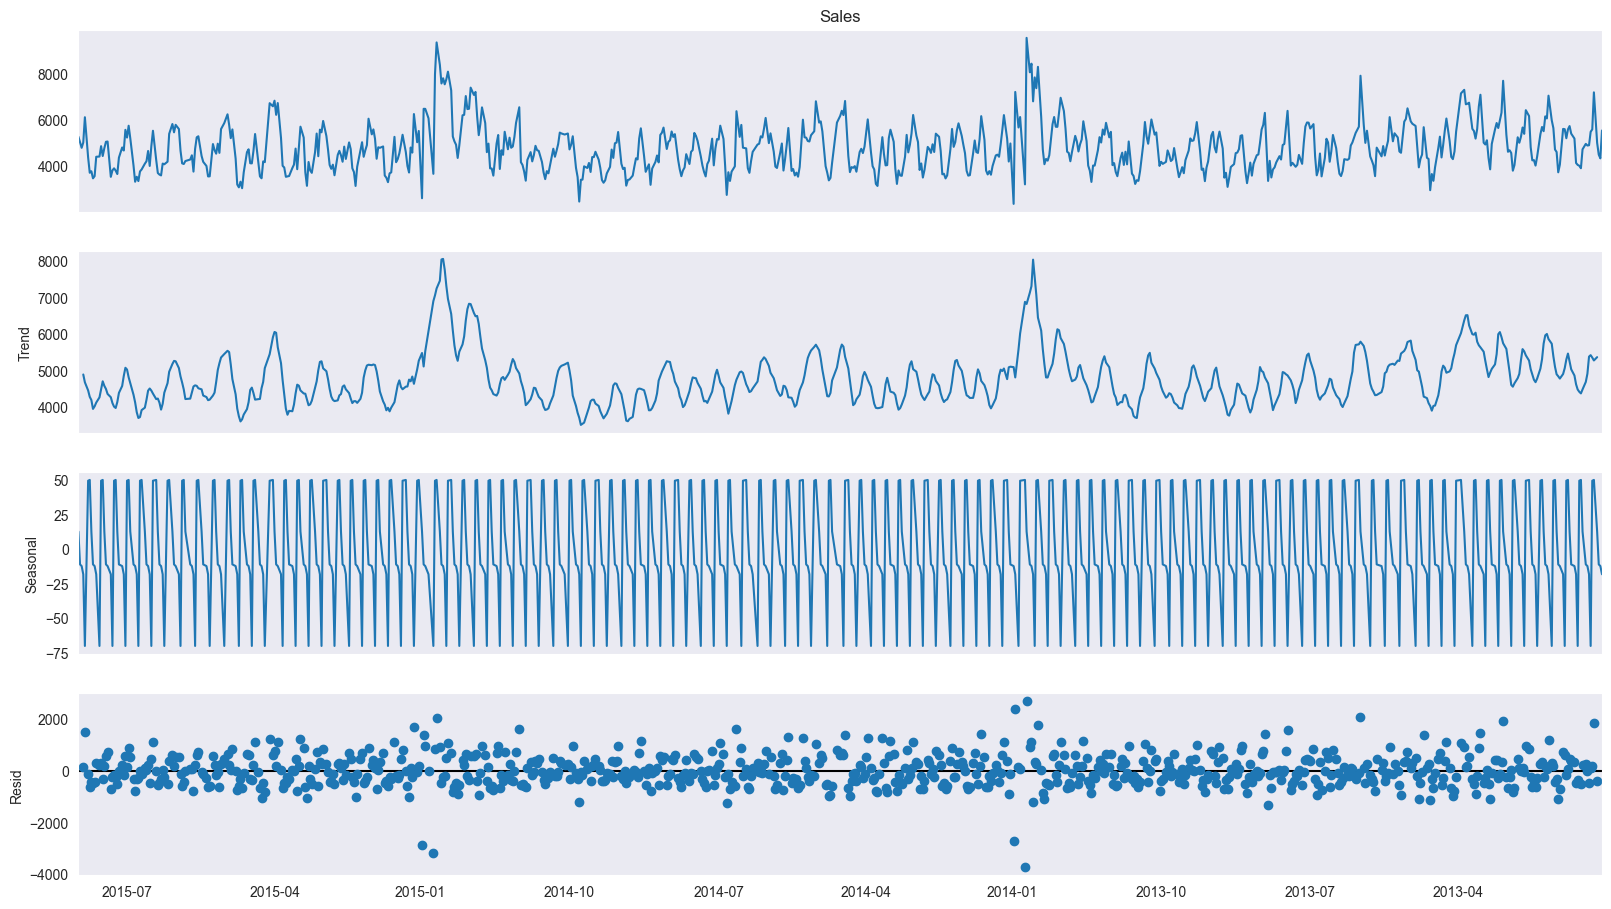

In [80]:
# Decompose the time series into trend, seasonality, and residual.
# Filter out zero sales for multiplicative decomposition
store1_sales_filtered = store1['Sales'][store1['Sales'] > 0]

decomposition = seasonal_decompose(store1_sales_filtered,
                                   model='additive',
                                   period=7)
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()



 **Seasonal Decomposition Analysis - Store 1**

The time series was decomposed into three fundamental components:

1.  **Trend:** Sales remain relatively stable with no long-term growth or decline. Notable peaks appear around December/January (Christmas effect), and a visible dip in mid-2014 corresponds to the store refurbishment period.
2.  **Seasonal:** A strong, consistent weekly cycle is evident throughout the entire dataset. This confirms the recurring pattern of high Monday sales and zero Sunday sales observed during EDA.
3.  **Residual:** The residuals are mostly centered around zero with no visible patterns, indicating that the decomposition successfully captured the main signals. A few outlier points (±2,000) represent rare, unpredictable events not explained by trend or seasonality.

**Conclusion:** The decomposition validates that our time series has a **strong seasonal component** and a **stable trend**, making it well-suited for seasonal forecasting models like SARIMA and Holt-Winters.


### **Stationarity vs non-stationary time series**

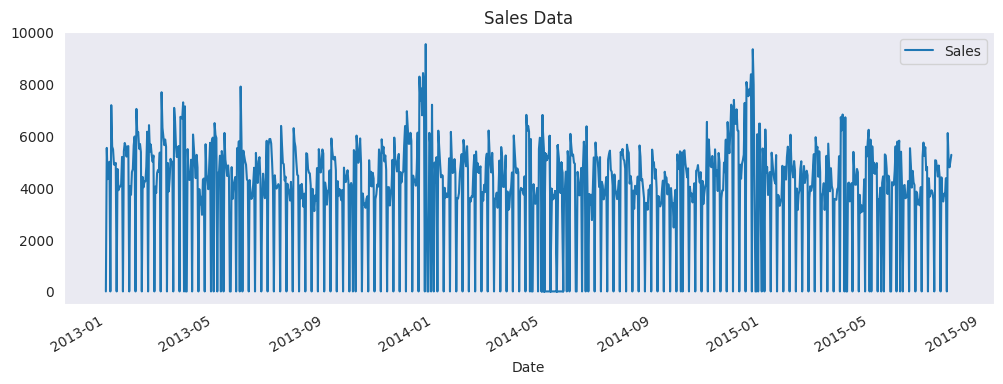

In [ ]:
store1['Sales'].plot(figsize=(12, 4))
plt.legend(loc='best')
plt.title('Sales Data')
plt.show(block=False)

**Augmented Dickey-Fuller (ADF) test**

In [81]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(store1['Sales'])

print('ADF Statistic: %f' % adf_test[0])
print('Critical Values @ 0.05: %.2f' % adf_test[4]['5%'])
print('p-value: %f' % adf_test[1])

ADF Statistic: -4.374784
Critical Values @ 0.05: -2.86
p-value: 0.000329


**ADF Test Result:**
The ADF statistic (-4.37) is significantly lower than the critical value at 5% (-2.86), and the p-value (0.000329) is well below 0.05. We therefore **reject the null hypothesis** and conclude that Store 1's sales time series is **Stationary**. No differencing is required before applying ARIMA-based models.

**Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test**

In [82]:
from statsmodels.tsa.stattools import kpss
kpss_test = kpss(store1['Sales'])

print('KPSS Statistic: %f' % kpss_test[0])
print('Critical Values @ 0.05: %.2f' % kpss_test[3]['5%'])
print('p-value: %f' % kpss_test[1])

KPSS Statistic: 0.268694
Critical Values @ 0.05: 0.46
p-value: 0.100000


C:\Users\MSI\AppData\Local\Temp\ipykernel_3840\3101098554.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(store1['Sales'])


The p-value is 0.1 is higher than 0.05 and so according to KPSS the series is Stationary.

**Autocorrelation function (ACF) and PACF as subplots**

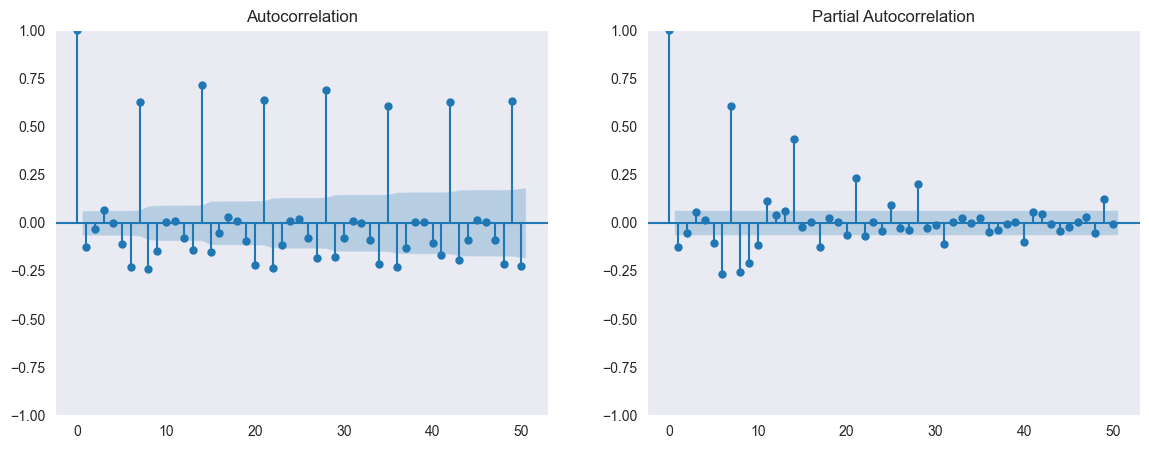

In [83]:

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(1,2,figsize=(14,5))
plot_acf(store1['Sales'].squeeze(), lags=50, ax=ax[0])
plot_pacf(store1['Sales'].squeeze(), lags=50, ax=ax[1])
plt.show()

q=14,p=7

**SETTING TIME SERIES FREQUENCY**

In [84]:
# Inspect the DateTimeIndex
store1.index

DatetimeIndex(['2015-07-31', '2015-07-30', '2015-07-29', '2015-07-28',
               '2015-07-27', '2015-07-26', '2015-07-25', '2015-07-24',
               '2015-07-23', '2015-07-22',
               ...
               '2013-01-10', '2013-01-09', '2013-01-08', '2013-01-07',
               '2013-01-06', '2013-01-05', '2013-01-04', '2013-01-03',
               '2013-01-02', '2013-01-01'],
              dtype='datetime64[us]', name='Date', length=942, freq=None)

In [85]:
# Check for duplicate index values
print(store1.index.duplicated().all())

False


In [86]:
store1.duplicated().sum()

np.int64(146)

In [87]:
# Convert the DataFrame to have weekly frequency (Mon-based).
data = store1.asfreq('D')
data.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2015-07-22', '2015-07-23', '2015-07-24', '2015-07-25',
               '2015-07-26', '2015-07-27', '2015-07-28', '2015-07-29',
               '2015-07-30', '2015-07-31'],
              dtype='datetime64[us]', name='Date', length=942, freq='D')

# Training and Test


**Split time series data into training and test keeping 36 rows for test (6 weeks)**

In [88]:
data.head()
print("Number of Rows in DS 1:", len(data))

Number of Rows in DS 1: 942


In [89]:
test_len = 36
train_len = len(data) - test_len
print(train_len)

906


In [90]:
train = data.iloc[0:train_len, :].Sales
test = data.iloc[train_len:,:].Sales

In [91]:
train.shape

(906,)

In [92]:
test.shape

(36,)

## **Simple Exponential Smoothing**

In [93]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing,Holt

In [94]:
# Fit a Simple Exponential Smoothing model on the training set
ses_model = SimpleExpSmoothing(train).fit()
print(ses_model.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                  Sales   No. Observations:                  906
Model:             SimpleExpSmoothing   SSE                     3975093132.475
Optimized:                       True   AIC                          13860.613
Trend:                           None   BIC                          13870.231
Seasonal:                        None   AICC                         13860.657
Seasonal Periods:                None   Date:                 Tue, 05 May 2026
Box-Cox:                        False   Time:                         17:19:29
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.0609214                alpha                 True
initial_level               0.000000                



### Smoothing Parameter (α = 0.0609)

The smoothing parameter **α** is the most critical output of this model. It controls how much weight the model gives to **recent vs. historical** observations.

- **6%** of the weight goes to the **most recent observation**
- **94%** of the weight goes to the **accumulated history** (previous forecasts)

> With α ≈ 0.06, the model essentially computes a **long-run weighted average** of all past sales rather than reacting to recent changes.

### Why Did the Optimizer Choose Such a Low α?

- Store 1 has **high daily volatility** — sales fluctuate significantly due to promotions, day-of-week effects, holidays, and random noise.
- The optimizer "learned" that **chasing short-term fluctuations increases error**, so it chose to smooth heavily instead.
- With α ≈ 0.06, the model needs roughly **1/α ≈ 16 days** of data before it meaningfully adjusts to a new sales level.


- The forecast is an **almost flat horizontal line** — every future day receives approximately the **same predicted value** (close to the overall training mean).
- The model **cannot react** to sudden changes such as promotions, holidays, or store closures.

---


### SSE (Sum of Squared Errors) = ~3.97 Billion

The SSE appears enormous at first glance, but this is expected when squaring daily sales errors that are already in the thousands.

To put it in a more interpretable scale:

- **SSE** = 3,975,093,132
- **RMSE** = √(SSE / n) = √(3,975,093,132 / 906) ≈ **2,094**
- **Average Daily Sales** for Store 1 is approximately **5,000 – 7,000**
- This means the model is off by roughly **30% – 40%** on average


> The model is off by roughly **2,094 units per day** on average — a **poor fit**, which is expected from a model that ignores both trend and seasonality.

---


> **SES confirms that Store 1's sales are too complex to be captured by a simple level-only model.**
> The high error (~30–40%) and the very low α (0.06) are clear signals that we need models incorporating **weekly seasonality**, **trend**, and **exogenous variables** (promotions, holidays) to produce accurate forecasts.


In [95]:
# Forecast the next 13 weeks using the fitted model
ses_pred = ses_model.forecast(test_len)
ses_pred

2015-06-26    3539.104024
2015-06-27    3539.104024
2015-06-28    3539.104024
2015-06-29    3539.104024
2015-06-30    3539.104024
2015-07-01    3539.104024
2015-07-02    3539.104024
2015-07-03    3539.104024
2015-07-04    3539.104024
2015-07-05    3539.104024
2015-07-06    3539.104024
2015-07-07    3539.104024
2015-07-08    3539.104024
2015-07-09    3539.104024
2015-07-10    3539.104024
2015-07-11    3539.104024
2015-07-12    3539.104024
2015-07-13    3539.104024
2015-07-14    3539.104024
2015-07-15    3539.104024
2015-07-16    3539.104024
2015-07-17    3539.104024
2015-07-18    3539.104024
2015-07-19    3539.104024
2015-07-20    3539.104024
2015-07-21    3539.104024
2015-07-22    3539.104024
2015-07-23    3539.104024
2015-07-24    3539.104024
2015-07-25    3539.104024
2015-07-26    3539.104024
2015-07-27    3539.104024
2015-07-28    3539.104024
2015-07-29    3539.104024
2015-07-30    3539.104024
2015-07-31    3539.104024
Freq: D, dtype: float64

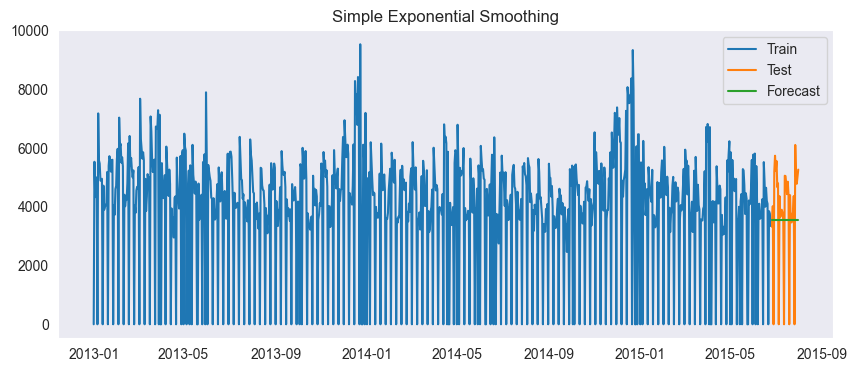

In [96]:
# Set the size of the plot of 10 by 4
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast data
plt.plot(train, label = "Train")
plt.plot(test, label = "Test")
plt.plot(ses_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Simple Exponential Smoothing")
plt.legend()
plt.show()

 **The Flat-Line Forecast (Confirmed)**

 
**The Forecast Misses Everything**

Looking at the test period (orange), the actual sales oscillate between ~3,000 and ~6,000 with clear ups and downs. The flat green forecast line:

Underestimates sales on high days (misses peaks around 5,000–6,000)
Overestimates sales on low days (especially the drops near 0 on closed days)
Cannot capture the weekly rhythm that is clearly visible in the orange line

**No Trend Captured**

Looking at the full blue line from 2013 to 2015, there appears to be a slight downward drift in the average sales level over time. SES with Trend = None completely ignores this, which adds to the forecast error.

### Double exponential smoothing

In [97]:
# Build a double exponential smoothing model (trend="add" for additive trend)
model_double = ExponentialSmoothing(
    endog=train,
    trend="add",
    seasonal=None
).fit()
print(model_double.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    Sales   No. Observations:                  906
Model:             ExponentialSmoothing   SSE                     3818275163.903
Optimized:                         True   AIC                          13828.147
Trend:                         Additive   BIC                          13847.383
Seasonal:                          None   AICC                         13828.240
Seasonal Periods:                  None   Date:                 Tue, 05 May 2026
Box-Cox:                          False   Time:                         17:54:36
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.0358933                alpha                 True
smoothing_trend            0.00175

Both α and β being very low tells us the same story as SES — Store 1's daily noise is so high that the optimizer prefers to smooth everything heavily rather than chase fluctuations.

Despite the improvement, Holt's model still ignores:

Weekly seasonality — the strong Monday-to-Sunday cycle visible in the data
Sunday closures — the regular drops to 0 every 7 days
Promotions — sudden spikes in sales caused by marketing campaigns
Holidays — Christmas, Easter, and other seasonal effects
School holidays — changes in shopping behavior during vacation periods

In [98]:
# Forecast with the double ES model
double_pred = model_double.forecast(test_len)
double_pred

2015-06-26    3566.801998
2015-06-27    3566.569346
2015-06-28    3566.336693
2015-06-29    3566.104041
2015-06-30    3565.871388
2015-07-01    3565.638736
2015-07-02    3565.406083
2015-07-03    3565.173431
2015-07-04    3564.940778
2015-07-05    3564.708126
2015-07-06    3564.475473
2015-07-07    3564.242821
2015-07-08    3564.010168
2015-07-09    3563.777516
2015-07-10    3563.544863
2015-07-11    3563.312211
2015-07-12    3563.079558
2015-07-13    3562.846906
2015-07-14    3562.614253
2015-07-15    3562.381601
2015-07-16    3562.148948
2015-07-17    3561.916296
2015-07-18    3561.683643
2015-07-19    3561.450991
2015-07-20    3561.218338
2015-07-21    3560.985686
2015-07-22    3560.753033
2015-07-23    3560.520381
2015-07-24    3560.287728
2015-07-25    3560.055076
2015-07-26    3559.822423
2015-07-27    3559.589771
2015-07-28    3559.357118
2015-07-29    3559.124466
2015-07-30    3558.891813
2015-07-31    3558.659161
Freq: D, dtype: float64

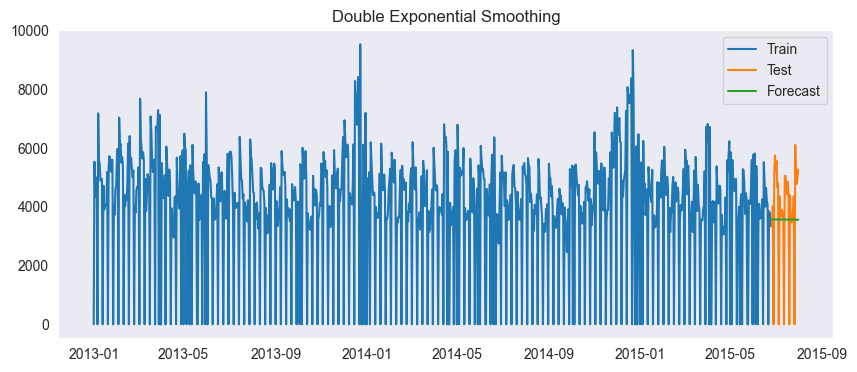

In [99]:
# Plot the train, test and forecast
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast data
plt.plot(train, label = "Train")
plt.plot(test, label = "Test")
plt.plot(double_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Double Exponential Smoothing")
plt.legend()
plt.show()


**Holt Winter aka Tripe Exponential Smoothing**

This is the first model that includes seasonality. It adds a weekly seasonal component (period = 7) on top of the level and trend, allowing the model to learn a repeating 7-day pattern.

SES: Forecast = Level only → flat line
Holt's: Forecast = Level + Trend → declining straight line
Holt-Winters: Forecast = Level + Trend + Seasonal Pattern → oscillating wave

In [105]:
# Build the Holt-Winters model with both trend and seasonality
model_holt = ExponentialSmoothing(
    endog=train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit()
print(model_holt.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    Sales   No. Observations:                  906
Model:             ExponentialSmoothing   SSE                     1282352837.086
Optimized:                         True   AIC                          12853.608
Trend:                         Additive   BIC                          12906.508
Seasonal:                      Additive   AICC                         12854.016
Seasonal Periods:                     7   Date:                 Tue, 05 May 2026
Box-Cox:                          False   Time:                         18:24:38
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.0552723                alpha                 True
smoothing_trend          

In [104]:
holt_pred = model_holt.forecast(test_len)
holt_pred[:5]

2015-06-26    4029.037716
2015-06-27    4548.904975
2015-06-28    -440.847688
2015-06-29    4484.016733
2015-06-30    4208.184402
Freq: D, dtype: float64

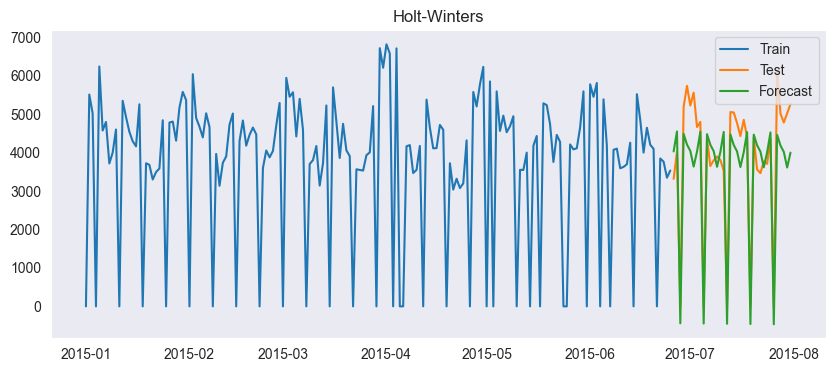

In [102]:
# Plot the Train, Test and Forecast
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast
plt.plot(train.loc['2015'], label = "Train")
plt.plot(test, label = "Test")
plt.plot(holt_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Holt-Winters")
plt.legend()
plt.show()

In [106]:
# Evaluate the forecast using RMSE, MAE, MAPE
rmse = root_mean_squared_error(test, holt_pred)
mae = mean_absolute_error(test, holt_pred)
mape = mean_absolute_percentage_error(test, holt_pred)
print(f"RMSE: {rmse:.0f}")
print(f"MAE: {mae:.0f}")
print(f"MAPE: {100 * mape:.1f} %")

RMSE: 801
MAE: 663
MAPE: 28356954901640310784.0 %


Holt-Winters is a massive leap forward. By adding a 7-day seasonal component, the model reduced RMSE by 43% and AIC by ~1,000 points compared to SES. The seasonal indices reveal that Sunday closures (s.5 = -4,222) are the single most impactful pattern, and Saturday (s.6 = +1,100) is the strongest sales day. However, with β frozen at exactly zero, the trend component adds minimal value. The model still cannot capture promotions, holidays, or irregular events these require either exogenous variables (SARIMAX) or machine learning approaches. Holt-Winters is the best classical exponential smoothing model for this data,